# Notebook 01 - Data ingestion, alignment, and EDA (DepMap backbone)

This notebook ingests the DepMap release (RNA, CNV, damaging mutations, PRISM AUC) and prepares three proteomics arms for fair comparison:

- **CCLE MS (Gygi)**
- **CCLE RPPA**
- **ProCan–DepMapSanger (mapped to DepMap IDs)**
- **Combined proteomics (MS + RPPA + ProCan; namespaced union)**

Outputs are written to `artifacts/` as cached Parquets plus a `lock.json` capturing file fingerprints and key decisions.

## What this notebook produces

**Metadata**
- `artifacts/metadata/notebook 1/lock.json`
- `artifacts/metadata/notebook 1/cell_metadata_depmap.parquet`
- `artifacts/metadata/notebook 1/track1_summary.json`
- `artifacts/metadata/notebook 1/feature_inventory.json`
- `artifacts/metadata/notebook 1/dataset_info.json`

**Aligned Parquets**
- Track 1 (per proteomics arm): `artifacts/aligned/notebook 1/track1_intersection/<arm>/*`
- Track 2 (core backbone + optional proteomics + masks): `artifacts/aligned/notebook 1/track2_nonintersection/*`

**EDA reports (PNGs + CSV)**
- Missingness summary CSV + plots: `artifacts/reports/notebook 1/*`
- Coverage plots (PRISM), missingness heatmaps (subset), proteomics left-censoring proxy plots, and lineage distribution.

> Notes: To keep runtime reasonable, plots that require scanning many features use sub-sampling.


In [1]:
import os
import re
import json
import hashlib
from datetime import datetime, timezone
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

# Reproducibility for subsampling in plots
RNG = np.random.default_rng(19537)


In [2]:
NOTEBOOK_SUBDIR = "notebook 1"

DATA_ROOT = Path("data")
DEPMAP_RAW = DATA_ROOT / "depmap" / "raw"
STRING_RAW = DATA_ROOT / "string_ppi" / "raw" / "v12.0"
PROCAN_PROCESSED = DATA_ROOT / "procan_depmapSanger" / "processed"

ARTIFACTS = Path("artifacts")
OUT_ALIGNED = ARTIFACTS / "aligned" / NOTEBOOK_SUBDIR
OUT_REPORTS = ARTIFACTS / "reports" / NOTEBOOK_SUBDIR
OUT_META    = ARTIFACTS / "metadata" / NOTEBOOK_SUBDIR

for d in [
    OUT_ALIGNED,
    OUT_REPORTS,
    OUT_META,
    ARTIFACTS / "splits",
    ARTIFACTS / "panels",
]:
    d.mkdir(parents=True, exist_ok=True)

DEPMAP_RELEASE = "25Q3"
STRING_VERSION = "12.0"

PROT_MAX_MISSING_FRAC = 0.95   # drop proteins missing in >95% of cell lines (arm-specific)

PRISM_MIN_LINES_PER_DRUG = 200

PRISM_PRIMARY_TAG = "lfc"     # primary target for the whole project
PRISM_SECONDARY_TAG = "auc"   # secondary experiment only

PRISM_LFC_RELEASE = "24Q2"
PRISM_AUC_RELEASE = DEPMAP_RELEASE 

META_COLS = [
    "depmap_id",
    "cell_line_display_name",
    "lineage_1",
    "lineage_2",
    "lineage_3",
    "lineage_4",
    "lineage_6",
]

INPUT_FILES = {
    "depmap_rna": DEPMAP_RAW / "Expression_Public_25Q3_subsetted.csv",
    "depmap_cnv": DEPMAP_RAW / "Copy_Number_WGS_Public_25Q3_subsetted.csv",
    "depmap_mut": DEPMAP_RAW / "Damaging_Mutations_subsetted.csv",

    # PRIMARY target (LFC)
    "depmap_prism_lfc_primary": DEPMAP_RAW / "PRISM_Repurposing_Public_24Q2_subsetted.csv",

    # SECONDARY target (AUC)
    "depmap_prism_auc_secondary": DEPMAP_RAW / "Drug_sensitivity_AUC_(PRISM_Repurposing_Secondary_Screen)_subsetted.csv",

    "depmap_meta": DEPMAP_RAW / "Subtype_Matrix_Public_25Q3_subsetted.csv",

    "prot_ms_ccle_gygi": DEPMAP_RAW / "Harmonized_MS_CCLE_Gygi_subsetted.csv",
    "prot_rppa_ccle": DEPMAP_RAW / "Harmonized_RPPA_CCLE_subsetted.csv",

    "procan_depmap_index_parquet": PROCAN_PROCESSED / "procan_proteomics_depmap_index.parquet",

    "string_aliases": STRING_RAW / "9606.protein.aliases.v12.0.txt",
    "string_links": STRING_RAW / "9606.protein.links.v12.0.txt",
}

missing = [k for k, p in INPUT_FILES.items() if not p.exists()]
if missing:
    print("[WARN] Missing expected inputs:")
    for k in missing:
        print(" -", k, "->", INPUT_FILES[k])
else:
    print("All expected inputs found.")


All expected inputs found.


In [3]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def fingerprint(path: Path) -> dict:
    st = path.stat()
    return {
        "path": str(path.resolve()),
        "size_bytes": int(st.st_size),
        "mtime_utc": datetime.fromtimestamp(st.st_mtime, tz=timezone.utc).isoformat(),
        "sha256": sha256_file(path),
    }

lock = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "depmap_release": DEPMAP_RELEASE,
    "prism_releases": {"lfc": PRISM_LFC_RELEASE, "auc": PRISM_AUC_RELEASE},
    "string_version": STRING_VERSION,
    "notebook": NOTEBOOK_SUBDIR,
    "targets": {
        "primary": {
            "dataset": "PRISM",
            "metric": "LFC",
            "tag": PRISM_PRIMARY_TAG,
            "release": PRISM_LFC_RELEASE,
            "notes": "Replicate-collapsed log2 fold-change vs DMSO (Repurposing primary screen)"
        },
        "secondary": {
            "dataset": "PRISM",
            "metric": "AUC",
            "tag": PRISM_SECONDARY_TAG,
            "release": PRISM_AUC_RELEASE,
            "screen": "Secondary_Screen"
        }
    },    
    "proteomics_arms": {
        "prot_ms_ccle_gygi": "CCLE MS proteomics (Gygi)",
        "prot_rppa_ccle": "CCLE RPPA proteomics",
        "prot_procan_depmapSanger": "ProCan–DepMapSanger (mapped to DepMap IDs)",
        "prot_combined_union": "Combined proteomics arm: MS + RPPA + ProCan (namespaced union on depmap_id)",
    },
    "files_used": {},
    "decisions": {
        "canonical_cell_id": "depmap_id",
        "rna_handling": "numeric coercion; keep all genes",
        "cnv_duplicate_collapse": "mean",
        "mutations_binarise": ">0 => 1 else 0 (int8); duplicates collapsed by max",
        "prot_ms_gene_mapping": "extract text in parentheses; collapse duplicates by mean",
        "track1": "clean ablations using intersection over (RNA,CNV,MUT,PROT_arm) with PRISM wide target",
        "track2": "core (RNA,CNV,MUT) with modality masks; PRISM long pairs for multi-drug modelling; PROT optional per arm",
        "prot_feature_missingness_filter": f"drop proteins with >{int(PROT_MAX_MISSING_FRAC*100)}% missing (per arm, global)",
        "prism_eligible_compounds_rule": f"save compounds with >= {PRISM_MIN_LINES_PER_DRUG} measured cell lines (no filtering applied here)",
        "prot_combined_union_definition": "outer-join on depmap_id; concatenate namespaced features: ms__*, rppa__*, procan__*; then apply the same missingness filter threshold",
    },
}

for k, p in INPUT_FILES.items():
    if p.exists():
        lock["files_used"][k] = fingerprint(p)

lock_path = OUT_META / "lock.json"
with lock_path.open("w", encoding="utf-8") as f:
    json.dump(lock, f, indent=2)

print("Wrote:", lock_path)


Wrote: artifacts\metadata\notebook 1\lock.json


In [4]:
def read_depmap_matrix(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, low_memory=False)
    df.index = df.index.astype(str)
    return df

rna_raw  = read_depmap_matrix(INPUT_FILES["depmap_rna"])
cnv_raw  = read_depmap_matrix(INPUT_FILES["depmap_cnv"])
mut_raw  = read_depmap_matrix(INPUT_FILES["depmap_mut"])
prism_lfc_raw = read_depmap_matrix(INPUT_FILES["depmap_prism_lfc_primary"])
prism_auc_raw = read_depmap_matrix(INPUT_FILES["depmap_prism_auc_secondary"])

prot_ms_raw = read_depmap_matrix(INPUT_FILES["prot_ms_ccle_gygi"])
prot_rppa_raw = read_depmap_matrix(INPUT_FILES["prot_rppa_ccle"])

meta_raw = pd.read_csv(INPUT_FILES["depmap_meta"], low_memory=False)
if "depmap_id" not in meta_raw.columns:
    meta_raw = meta_raw.rename(columns={meta_raw.columns[0]: "depmap_id"})
meta_raw["depmap_id"] = meta_raw["depmap_id"].astype(str)

procan_df = None
if INPUT_FILES["procan_depmap_index_parquet"].exists():
    procan_df = pd.read_parquet(INPUT_FILES["procan_depmap_index_parquet"])
    if "depmap_id" in procan_df.columns:
        procan_df["depmap_id"] = procan_df["depmap_id"].astype(str)
        procan_df = procan_df.set_index("depmap_id")
    procan_df.index = procan_df.index.astype(str)
    procan_df.index.name = "depmap_id"

print("RNA:", rna_raw.shape)
print("CNV:", cnv_raw.shape)
print("MUT:", mut_raw.shape)
print("PRISM LFC (primary):", prism_lfc_raw.shape)
print("PRISM AUC (secondary):", prism_auc_raw.shape)
print("PROT MS (Gygi):", prot_ms_raw.shape)
print("PROT RPPA:", prot_rppa_raw.shape)
print("ProCan (mapped):", None if procan_df is None else procan_df.shape)

display(rna_raw.iloc[:3, :5])
display(prot_ms_raw.iloc[:3, :5])
display(prot_rppa_raw.iloc[:3, :5])
display(prism_lfc_raw.iloc[:3, :5])
display(prism_auc_raw.iloc[:3, :5])


RNA: (1699, 19218)
CNV: (1095, 19366)
MUT: (1955, 19542)
PRISM LFC (primary): (915, 6767)
PRISM AUC (secondary): (480, 1456)
PROT MS (Gygi): (375, 12564)
PROT RPPA: (898, 150)
ProCan (mapped): (917, 8453)


,cell_line_display_name,lineage_1,lineage_2,lineage_3,lineage_6
depmap_id,,,,,
ACH-001270,127399,Soft Tissue,Synovial Sarcoma,Synovial Sarcoma,NaN
ACH-002680,170MGBA,CNS/Brain,Diffuse Glioma,Glioblastoma,NaN
ACH-001438,1777NRPMET,Testis,Non-Seminomatous Germ Cell Tumor,Embryonal Carcinoma,NaN


,cell_line_display_name,lineage_1,lineage_2,lineage_3,lineage_6
depmap_id,,,,,
ACH-000248,AU565,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,HER2+
ACH-000536,BT20,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,Basal A TNBC
ACH-000288,BT549,Breast,Invasive Breast Carcinoma,"Breast Invasive Carcinoma, NOS",Basal B TNBC


,cell_line_display_name,lineage_1,lineage_2,lineage_3,lineage_6
depmap_id,,,,,
ACH-000520,59M,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NaN
ACH-000973,639V,Bladder/Urinary Tract,Urethral Cancer,Urethral Urothelial Carcinoma,NaN
ACH-000248,AU565,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,HER2+


,ARV-825 (BRD:BRD-A00047421-001-01-7),RS-0481 (BRD:BRD-A00055058-001-01-0),8-BROMO-CGMP (BRD:BRD-A00077618-236-07-6),DOCUSATE (BRD:BRD-A00092689-236-04-9),NIFURTIMOX (BRD:BRD-A00100033-001-08-9)
ACH-000001,-1.207281,0.515743,-0.015577,-0.395123,-0.449332
ACH-000002,-4.231563,NaN,NaN,-0.538376,NaN
ACH-000004,-3.860672,NaN,NaN,0.306971,NaN


,cell_line_display_name,lineage_1,lineage_2,lineage_3,lineage_6
depmap_id,,,,,
ACH-000973,639V,Bladder/Urinary Tract,Urethral Cancer,Urethral Urothelial Carcinoma,NaN
ACH-001016,BECKER,CNS/Brain,Diffuse Glioma,Astrocytoma,NaN
ACH-000927,BT474,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,"ER+, PR+, HER2+"


In [5]:
def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    return df.apply(pd.to_numeric, errors="coerce")

def extract_gene_from_parentheses(col: str) -> str:
    m = re.search(r"\(([^)]+)\)", str(col))
    return m.group(1).strip() if m else str(col).strip()

def drop_meta_cols(df: pd.DataFrame) -> pd.DataFrame:
    drop_cols = [c for c in META_COLS if c in df.columns]
    return df.drop(columns=drop_cols, errors="ignore")

def filter_proteomics_by_missingness(
    prot: pd.DataFrame,
    arm_name: str,
    max_missing_frac: float,
    out_reports_dir: Path,
    out_meta_dir: Path,
):
    """
    Drops proteins with missingness > max_missing_frac (i.e., observed in < (1-max_missing_frac) fraction of lines).
    Saves: per-protein missingness CSV, keep-mask parquet, and a small JSON summary.
    """
    if prot is None or prot.shape[1] == 0:
        summary = {
            "arm": arm_name,
            "n_cells": int(prot.shape[0]) if prot is not None else 0,
            "n_proteins_before": 0,
            "n_proteins_after": 0,
            "dropped_reason": "empty",
            "max_missing_frac": float(max_missing_frac),
        }
        return prot, summary

    miss_frac = prot.isna().mean(axis=0)
    keep = miss_frac.le(max_missing_frac) & miss_frac.notna()

    # Save per-protein missingness table (useful for reviewers)
    miss_tbl = miss_frac.rename("missing_frac").to_frame()
    miss_tbl["keep"] = keep.astype(int).values
    miss_tbl.sort_values("missing_frac", ascending=False).to_csv(
        out_reports_dir / f"proteomics__{arm_name}__missingness_by_protein.csv"
    )

    # Save keep-mask (so downstream notebooks can reproduce the same feature set if desired)
    keep_mask = pd.DataFrame({"protein": miss_tbl.index.astype(str), "keep": keep.astype(np.int8).values})
    keep_mask_path = out_meta_dir / f"proteomics__{arm_name}__protein_keep_mask.parquet"
    keep_mask.to_parquet(keep_mask_path, index=False)

    filtered = prot.loc[:, keep.values].copy()

    summary = {
        "arm": arm_name,
        "n_cells": int(prot.shape[0]),
        "n_proteins_before": int(prot.shape[1]),
        "n_proteins_after": int(filtered.shape[1]),
        "n_dropped": int((~keep).sum()),
        "max_missing_frac": float(max_missing_frac),
        "keep_mask_path": str(keep_mask_path),
    }
    return filtered, summary


def audit_rppa_zeros(prot_rppa: pd.DataFrame, out_reports_dir: Path):
    """
    RPPA often has no NaNs. This checks whether zeros might be acting like a missing-value sentinel.
    Saves per-protein zero fraction + basic min/max.
    """
    if prot_rppa is None or prot_rppa.shape[1] == 0:
        print("[RPPA zero-check] skipped (empty).")
        return

    # fraction of exact zeros per protein (column)
    zero_frac = (prot_rppa == 0).mean(axis=0).rename("zero_frac").to_frame()
    mins = prot_rppa.min(axis=0).rename("min").to_frame()
    maxs = prot_rppa.max(axis=0).rename("max").to_frame()
    stats = zero_frac.join(mins).join(maxs)

    stats.sort_values("zero_frac", ascending=False).to_csv(out_reports_dir / "rppa__zero_fraction_and_range_by_protein.csv")

    # quick console summary
    print("[RPPA zero-check] zero_frac quantiles:")
    display(stats["zero_frac"].quantile([0, 0.5, 0.9, 0.99, 1.0]).rename("zero_frac_quantiles").to_frame())

    n_high = int((stats["zero_frac"] > 0.50).sum())
    print(f"[RPPA zero-check] proteins with >50% zeros: {n_high} / {prot_rppa.shape[1]}")

# Cell metadata (from DepMap subtype/metadata matrix)
cell_meta = meta_raw[[c for c in META_COLS if c in meta_raw.columns]].copy()
cell_meta = cell_meta.dropna(subset=["depmap_id"]).drop_duplicates("depmap_id")
cell_meta = cell_meta.set_index("depmap_id")
cell_meta.index = cell_meta.index.astype(str)
for c in cell_meta.columns:
    cell_meta[c] = cell_meta[c].astype("string")

cell_meta_path = OUT_META / "cell_metadata_depmap.parquet"
cell_meta.to_parquet(cell_meta_path)
print("Saved:", cell_meta_path, cell_meta.shape)

# Clean matrices
rna = coerce_numeric(drop_meta_cols(rna_raw))
cnv = coerce_numeric(drop_meta_cols(cnv_raw))
mut = drop_meta_cols(mut_raw)

# PRISM: coerce numeric
prism_lfc_wide = coerce_numeric(drop_meta_cols(prism_lfc_raw))
prism_lfc_wide = prism_lfc_wide.dropna(axis=1, how="all")
prism_lfc_wide = prism_lfc_wide.loc[:, ~prism_lfc_wide.columns.duplicated()]

prism_auc_wide = coerce_numeric(drop_meta_cols(prism_auc_raw))
prism_auc_wide = prism_auc_wide.dropna(axis=1, how="all")
prism_auc_wide = prism_auc_wide.loc[:, ~prism_auc_wide.columns.duplicated()]

prism_primary_wide = prism_lfc_wide
prism_secondary_wide = prism_auc_wide

# Proteomics MS: map to gene symbols using parentheses and collapse duplicates
prot_ms = drop_meta_cols(prot_ms_raw).copy()
prot_ms.columns = [extract_gene_from_parentheses(c) for c in prot_ms.columns]
prot_ms = coerce_numeric(prot_ms)
prot_ms = prot_ms.T.groupby(level=0, sort=False).mean().T
prot_ms = prot_ms.dropna(axis=1, how="all")

# Proteomics RPPA: collapse duplicates (if any)
prot_rppa = coerce_numeric(drop_meta_cols(prot_rppa_raw))
prot_rppa = prot_rppa.T.groupby(level=0, sort=False).mean().T

# Mutations: binarise and collapse duplicates by max
mut = coerce_numeric(mut).fillna(0.0)
mut = (mut > 0).astype(np.int8)
mut = mut.T.groupby(level=0, sort=False).max().T

# CNV: collapse duplicates by mean
cnv = cnv.T.groupby(level=0, sort=False).mean().T

prot_filter_summaries = []

prot_ms, s_ms = filter_proteomics_by_missingness(
    prot_ms, "prot_ms_ccle_gygi", PROT_MAX_MISSING_FRAC, OUT_REPORTS, OUT_META
)
prot_filter_summaries.append(s_ms)

prot_rppa, s_rppa = filter_proteomics_by_missingness(
    prot_rppa, "prot_rppa_ccle", PROT_MAX_MISSING_FRAC, OUT_REPORTS, OUT_META
)
prot_filter_summaries.append(s_rppa)

if procan_df is not None and procan_df.shape[1] > 0:
    procan_df, s_procan = filter_proteomics_by_missingness(
        procan_df, "prot_procan_depmapSanger", PROT_MAX_MISSING_FRAC, OUT_REPORTS, OUT_META
    )
else:
    s_procan = {
        "arm": "prot_procan_depmapSanger",
        "n_cells": int(0 if procan_df is None else procan_df.shape[0]),
        "n_proteins_before": int(0 if procan_df is None else procan_df.shape[1]),
        "n_proteins_after": int(0),
        "n_dropped": int(0),
        "max_missing_frac": float(PROT_MAX_MISSING_FRAC),
        "dropped_reason": "missing input parquet or empty frame",
    }
prot_filter_summaries.append(s_procan)


# RPPA zero-as-missing sanity check (because NaN-based missingness is 0) 
audit_rppa_zeros(prot_rppa, OUT_REPORTS)

# Combined proteomics arm (MS + RPPA + ProCan)
def _prefix_cols(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df is None or df.shape[1] == 0:
        return pd.DataFrame(index=pd.Index([], name="depmap_id"))
    out = df.copy()
    out.index = out.index.astype(str)
    out.index.name = "depmap_id"
    out.columns = [f"{prefix}__{str(c)}" for c in out.columns]
    return out

prot_ms_ns    = _prefix_cols(prot_ms, "ms")
prot_rppa_ns  = _prefix_cols(prot_rppa, "rppa")
procan_ns     = _prefix_cols(procan_df, "procan") if procan_df is not None else pd.DataFrame(index=pd.Index([], name="depmap_id"))

prot_combined_union = pd.concat([prot_ms_ns, prot_rppa_ns, procan_ns], axis=1, join="outer", sort=False)

# Drop any rows that accidentally have no observed proteomics values at all
if prot_combined_union.shape[1] > 0:
    prot_combined_union = prot_combined_union.loc[prot_combined_union.notna().any(axis=1)]

# Same missingness filter threshold to the combined arm 
prot_combined_union, s_combined = filter_proteomics_by_missingness(
    prot_combined_union,
    "prot_combined_union",
    PROT_MAX_MISSING_FRAC,
    OUT_REPORTS,
    OUT_META
)
prot_filter_summaries.append(s_combined)

prot_filter_summary_df = pd.DataFrame(prot_filter_summaries)
display(prot_filter_summary_df)
prot_filter_summary_df.to_csv(OUT_REPORTS / "proteomics__filtering_summary.csv", index=False)

with (OUT_META / "proteomics__filtering_summary.json").open("w", encoding="utf-8") as f:
    json.dump(prot_filter_summaries, f, indent=2)

print("Saved proteomics filtering reports to:", OUT_REPORTS, "and", OUT_META)

empty_prot = pd.DataFrame(index=pd.Index([], name="depmap_id"))

proteomics_arms = {
    "prot_ms_ccle_gygi": prot_ms,
    "prot_rppa_ccle": prot_rppa,
    "prot_procan_depmapSanger": procan_df if procan_df is not None else empty_prot,
    "prot_combined_union": prot_combined_union,
}

print("Prepared matrices:")
print(" RNA:", rna.shape, "CNV:", cnv.shape, "MUT:", mut.shape,
      "PRISM LFC:", prism_lfc_wide.shape, "PRISM AUC:", prism_auc_wide.shape)
for k, v in proteomics_arms.items():
    print(f" {k}:", v.shape)


Saved: artifacts\metadata\notebook 1\cell_metadata_depmap.parquet (2132, 6)
[RPPA zero-check] zero_frac quantiles:


,zero_frac_quantiles
0.00,0.001114
0.50,0.001114
0.90,0.001114
0.99,0.001114
1.00,0.003341


[RPPA zero-check] proteins with >50% zeros: 0 / 144


,arm,n_cells,n_proteins_before,n_proteins_after,n_dropped,max_missing_frac,keep_mask_path
0,prot_ms_ccle_gygi,375,12126,11780,346,0.95,artifacts\metadata\notebook 1\proteomics__prot...
1,prot_rppa_ccle,898,144,144,0,0.95,artifacts\metadata\notebook 1\proteomics__prot...
2,prot_procan_depmapSanger,917,8453,7906,547,0.95,artifacts\metadata\notebook 1\proteomics__prot...
3,prot_combined_union,1239,19830,18751,1079,0.95,artifacts\metadata\notebook 1\proteomics__prot...


Saved proteomics filtering reports to: artifacts\reports\notebook 1 and artifacts\metadata\notebook 1
Prepared matrices:
 RNA: (1699, 19212) CNV: (1095, 19360) MUT: (1955, 19536) PRISM LFC: (915, 6767) PRISM AUC: (480, 1450)
 prot_ms_ccle_gygi: (375, 11780)
 prot_rppa_ccle: (898, 144)
 prot_procan_depmapSanger: (917, 7906)
 prot_combined_union: (1239, 18751)


In [6]:
def audit_missing(df: pd.DataFrame, name: str) -> pd.DataFrame:
    n_rows, n_cols = df.shape
    total = n_rows * n_cols
    miss = int(df.isna().sum().sum()) if total else 0
    pct = (miss / total * 100.0) if total else 0.0
    row_miss = df.isna().sum(axis=1) if n_cols else pd.Series([], dtype=int)
    col_miss = df.isna().sum(axis=0) if n_rows else pd.Series([], dtype=int)

    out = pd.DataFrame([{
        "dataset": name,
        "n_rows": n_rows,
        "n_cols": n_cols,
        "missing_total": miss,
        "missing_pct": pct,
        "rows_with_any_missing": int((row_miss > 0).sum()) if n_cols else 0,
        "cols_with_any_missing": int((col_miss > 0).sum()) if n_rows else 0,
        "max_missing_in_a_row": int(row_miss.max()) if n_rows and n_cols else 0,
        "max_missing_in_a_col": int(col_miss.max()) if n_rows and n_cols else 0,
    }])
    return out

rows = []
rows.append(audit_missing(rna, "RNA"))
rows.append(audit_missing(cnv, "CNV"))
rows.append(audit_missing(mut.astype(float), "MUT (binary)"))
rows.append(audit_missing(prism_lfc_wide, "PRISM LFC (wide, primary)"))
rows.append(audit_missing(prism_auc_wide, "PRISM AUC (wide, secondary)"))
for arm, df in proteomics_arms.items():
    rows.append(audit_missing(df, f"PROT: {arm}"))

missing_summary = pd.concat(rows, ignore_index=True)
display(missing_summary)

missing_summary_path = OUT_REPORTS / "missingness_summary.csv"
missing_summary.to_csv(missing_summary_path, index=False)
print("Saved:", missing_summary_path)

if prism_lfc_wide.shape[1] > 0:
    per_drug_lfc = prism_lfc_wide.notna().sum(axis=0).sort_values(ascending=False)
    per_drug_lfc.to_csv(OUT_REPORTS / "prism_lfc__measured_cell_lines_per_drug_full.csv")

    eligible = per_drug_lfc[per_drug_lfc >= PRISM_MIN_LINES_PER_DRUG].index.astype(str).tolist()
    with (OUT_META / f"prism_lfc__eligible_compounds__min{PRISM_MIN_LINES_PER_DRUG}_lines.json").open("w", encoding="utf-8") as f:
        json.dump(eligible, f, indent=2)

    print(f"Saved PRISM LFC eligible compound list (n={len(eligible)}) to:", OUT_META)


# AUC coverage (secondary)
if prism_auc_wide.shape[1] > 0:
    per_drug_auc = prism_auc_wide.notna().sum(axis=0).sort_values(ascending=False)
    per_drug_auc.to_csv(OUT_REPORTS / "prism_auc__measured_cell_lines_per_drug_full.csv")

    eligible_auc = per_drug_auc[per_drug_auc >= PRISM_MIN_LINES_PER_DRUG].index.astype(str).tolist()
    with (OUT_META / f"prism_auc__eligible_compounds__min{PRISM_MIN_LINES_PER_DRUG}_lines.json").open("w", encoding="utf-8") as f:
        json.dump(eligible_auc, f, indent=2)

    print(f"Saved PRISM AUC eligible compound list (n={len(eligible_auc)}) to:", OUT_META)

,dataset,n_rows,n_cols,missing_total,missing_pct,rows_with_any_missing,cols_with_any_missing,max_missing_in_a_row,max_missing_in_a_col
0,RNA,1699,19212,0,0.000000,0,0,0,0
1,CNV,1095,19360,824535,3.889463,1095,753,753,1095
2,MUT (binary),1955,19536,0,0.000000,0,0,0,0
3,"PRISM LFC (wide, primary)",915,6767,1998424,32.275306,812,6767,6527,469
4,"PRISM AUC (wide, secondary)",480,1450,302075,43.401580,480,1450,1108,478
5,PROT: prot_ms_ccle_gygi,375,11780,1103912,24.989519,375,6702,3862,350
6,PROT: prot_rppa_ccle,898,144,0,0.000000,0,0,0,0
7,PROT: prot_procan_depmapSanger,917,7906,2504138,34.540778,917,7082,5393,871
8,PROT: prot_combined_union,1239,18751,15089569,64.950290,1239,18751,18607,1177


Saved: artifacts\reports\notebook 1\missingness_summary.csv
Saved PRISM LFC eligible compound list (n=6767) to: artifacts\metadata\notebook 1
Saved PRISM AUC eligible compound list (n=964) to: artifacts\metadata\notebook 1


In [7]:
def save_parquet(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path)

def make_track1_for_arm(arm_name: str, prot_df: pd.DataFrame) -> dict:
    rna_cells = set(rna.index)
    cnv_cells = set(cnv.index)
    mut_cells = set(mut.index)
    prot_cells = set(prot_df.index)
    prism_cells = set(prism_primary_wide.index)
    common_cells = sorted(rna_cells & cnv_cells & mut_cells & prot_cells & prism_cells)

    prism_tmp = prism_primary_wide.loc[common_cells]
    common_cells = prism_tmp.index[prism_tmp.notna().sum(axis=1).gt(0)].tolist()

    out_dir = OUT_ALIGNED / "track1_intersection" / arm_name
    out_dir.mkdir(parents=True, exist_ok=True)

    rna_t1 = rna.loc[common_cells]
    cnv_t1 = cnv.loc[common_cells]
    mut_t1 = mut.loc[common_cells]
    prot_t1 = prot_df.loc[common_cells]
    prot_cov_t1 = prot_t1.notna().mean(axis=1).rename("prot_coverage").to_frame()
    prism_lfc_t1 = prism_lfc_wide.reindex(common_cells)
    prism_auc_t1 = prism_auc_wide.reindex(common_cells)
    meta_t1 = cell_meta.reindex(common_cells)

    save_parquet(meta_t1.reset_index(), out_dir / "cell_metadata.parquet")
    save_parquet(rna_t1,  out_dir / "rna.parquet")
    save_parquet(cnv_t1,  out_dir / "cnv.parquet")
    save_parquet(mut_t1,  out_dir / "mut.parquet")
    save_parquet(prot_t1, out_dir / "prot.parquet")
    save_parquet(prism_lfc_t1, out_dir / "prism_lfc_wide.parquet")
    save_parquet(prism_auc_t1, out_dir / "prism_auc_wide.parquet")
    save_parquet(prism_lfc_t1, out_dir / "prism_primary_wide.parquet")
    save_parquet(prism_auc_t1, out_dir / "prism_secondary_wide.parquet")
    save_parquet(prot_cov_t1, out_dir / "prot_coverage.parquet")


    return {
        "arm": arm_name,
        "n_cells": len(common_cells),
        "shapes": {
            "rna": list(rna_t1.shape),
            "cnv": list(cnv_t1.shape),
            "mut": list(mut_t1.shape),
            "prot": list(prot_t1.shape),
            "prism_lfc_wide": list(prism_lfc_t1.shape),
            "prism_auc_wide": list(prism_auc_t1.shape),
        }
    }

track1_summaries = []
for arm, prot_df in proteomics_arms.items():
    if prot_df.shape[1] == 0:
        print(f"[WARN] Skipping Track 1 for {arm} (no features loaded).")
        continue
    s = make_track1_for_arm(arm, prot_df)
    track1_summaries.append(s)
    print(f"Track 1 saved for {arm}: n_cells={s['n_cells']}")

track1_summary_df = pd.DataFrame(track1_summaries)
display(track1_summary_df)

track1_summary_path = OUT_META / "track1_summary.json"
with track1_summary_path.open("w", encoding="utf-8") as f:
    json.dump(track1_summaries, f, indent=2)
print("Saved:", track1_summary_path)


# Track 2 core backbone (RNA + CNV + MUT), with optional proteomics per arm + modality masks
rna_cells = set(rna.index)
cnv_cells = set(cnv.index)
mut_cells = set(mut.index)
core_cells = sorted(rna_cells & cnv_cells & mut_cells)

track2_dir = OUT_ALIGNED / "track2_nonintersection"
track2_dir.mkdir(parents=True, exist_ok=True)

rna_t2 = rna.reindex(core_cells)
cnv_t2 = cnv.reindex(core_cells)
mut_t2 = mut.reindex(core_cells)
prism_lfc_t2_wide = prism_lfc_wide.reindex(core_cells)
prism_auc_t2_wide = prism_auc_wide.reindex(core_cells)
save_parquet(rna_t2, track2_dir / "rna.parquet")
save_parquet(cnv_t2, track2_dir / "cnv.parquet")
save_parquet(mut_t2, track2_dir / "mut.parquet")

meta_t2 = cell_meta.reindex(core_cells)
save_parquet(meta_t2.reset_index(), track2_dir / "cell_metadata.parquet")

save_parquet(prism_lfc_t2_wide, track2_dir / "prism_lfc_wide.parquet")
save_parquet(prism_auc_t2_wide, track2_dir / "prism_auc_wide.parquet")

save_parquet(prism_lfc_t2_wide, track2_dir / "prism_primary_wide.parquet")
save_parquet(prism_auc_t2_wide, track2_dir / "prism_secondary_wide.parquet")

prism_lfc_pairs = (
    prism_lfc_t2_wide
    .stack(dropna=True)
    .rename("lfc")
    .reset_index()
    .rename(columns={"level_0": "depmap_id", "level_1": "compound"})
)
save_parquet(prism_lfc_pairs, track2_dir / "prism_lfc_pairs.parquet")
save_parquet(prism_lfc_pairs, track2_dir / "prism_primary_pairs.parquet")

prism_auc_pairs = (
    prism_auc_t2_wide
    .stack(dropna=True)
    .rename("auc")
    .reset_index()
    .rename(columns={"level_0": "depmap_id", "level_1": "compound"})
)
save_parquet(prism_auc_pairs, track2_dir / "prism_auc_pairs.parquet")
save_parquet(prism_auc_pairs, track2_dir / "prism_secondary_pairs.parquet")

print("Track 2 core saved:", {"n_cells": len(core_cells), "lfc_pairs": prism_lfc_pairs.shape, "auc_pairs": prism_auc_pairs.shape})

for arm, prot_df in proteomics_arms.items():
    prot_opt = prot_df.reindex(core_cells)
    save_parquet(prot_opt, track2_dir / f"prot_optional__{arm}.parquet")

    if prot_opt.shape[1] > 0:
        prot_cov_t2 = prot_opt.notna().mean(axis=1).rename("prot_coverage").to_frame()
        has_prot = prot_opt.notna().sum(axis=1).gt(0).astype(np.int8)
    else:
        prot_cov_t2 = pd.DataFrame({"prot_coverage": np.zeros(len(core_cells), dtype=float)}, index=core_cells)
        has_prot = pd.Series(0, index=core_cells, dtype=np.int8)

    save_parquet(prot_cov_t2, track2_dir / f"prot_coverage__{arm}.parquet")

    mask = pd.DataFrame(index=core_cells)
    mask["has_rna"] = 1
    mask["has_cnv"] = 1
    mask["has_mut"] = 1
    mask[f"has_{arm}"] = has_prot.values
    save_parquet(mask, track2_dir / f"modality_mask__{arm}.parquet")

print("Track 2 arm-specific proteomics + masks saved under:", track2_dir)


Track 1 saved for prot_ms_ccle_gygi: n_cells=277
Track 1 saved for prot_rppa_ccle: n_cells=505
Track 1 saved for prot_procan_depmapSanger: n_cells=395
Track 1 saved for prot_combined_union: n_cells=538


,arm,n_cells,shapes
0,prot_ms_ccle_gygi,277,"{'rna': [277, 19212], 'cnv': [277, 19360], 'mu..."
1,prot_rppa_ccle,505,"{'rna': [505, 19212], 'cnv': [505, 19360], 'mu..."
2,prot_procan_depmapSanger,395,"{'rna': [395, 19212], 'cnv': [395, 19360], 'mu..."
3,prot_combined_union,538,"{'rna': [538, 19212], 'cnv': [538, 19360], 'mu..."


Saved: artifacts\metadata\notebook 1\track1_summary.json


C:\Users\Owner\AppData\Local\Temp\ipykernel_31724\319944557.py:100: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_31724\319944557.py:110: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


Track 2 core saved: {'n_cells': 1079, 'lfc_pairs': (3112883, 3), 'auc_pairs': (306903, 3)}
Track 2 arm-specific proteomics + masks saved under: artifacts\aligned\notebook 1\track2_nonintersection


In [8]:
def write_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

inventory = {
    "depmap_release": DEPMAP_RELEASE,
    "string_version": STRING_VERSION,
    "rna_genes": list(map(str, rna.columns)),
    "cnv_genes": list(map(str, cnv.columns)),
    "mut_genes": list(map(str, mut.columns)),
    "proteomics_arms": {},
}

for arm, prot_df in proteomics_arms.items():
    inventory["proteomics_arms"][arm] = {
        "n_features": int(prot_df.shape[1]),
        "features": list(map(str, prot_df.columns))[:5000],  # avoid massive JSON
    }

write_json(inventory, OUT_META / "feature_inventory.json")
print("Saved:", OUT_META / "feature_inventory.json")

dataset_info = {
    "depmap_release": DEPMAP_RELEASE,
    "inputs": {k: str(v) for k, v in INPUT_FILES.items()},
    "shapes": {
        "rna": list(rna.shape),
        "cnv": list(cnv.shape),
        "mut": list(mut.shape),
        "prism_lfc_wide": list(prism_lfc_wide.shape),
        "prism_auc_wide": list(prism_auc_wide.shape),
        "proteomics_arms": {arm: list(df.shape) for arm, df in proteomics_arms.items()},
    },
}
write_json(dataset_info, OUT_META / "dataset_info.json")
print("Saved:", OUT_META / "dataset_info.json")


Saved: artifacts\metadata\notebook 1\feature_inventory.json
Saved: artifacts\metadata\notebook 1\dataset_info.json


## EDA

The goal here is *quick sanity checks* and *usefulness diagnostics*:

- Where missingness sits (cells vs features) for proteomics and PRISM.
- Whether proteomics missingness looks “left-censored” (low mean abundance → high missing fraction).
- PRISM coverage by drug and by cell line.
- Lineage distribution (helps spot imbalance).
- PCA sanity plots (very coarse structure checks).

All plots are saved into: `artifacts/reports/notebook 1/`.


EDA: Missingness histograms + heatmaps (subset)


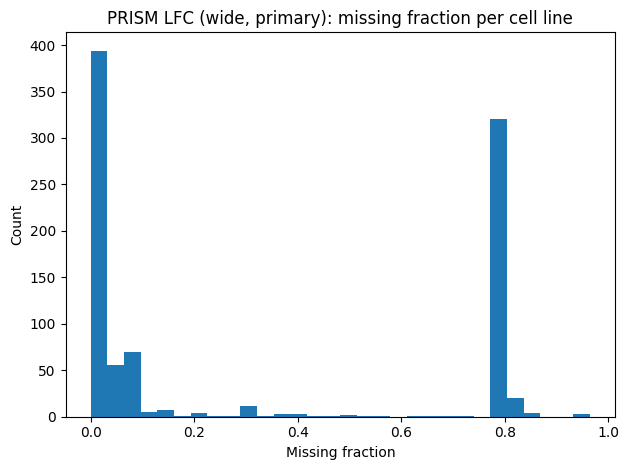

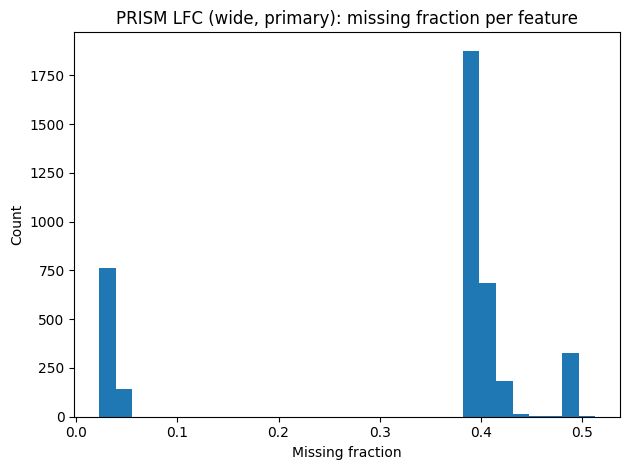

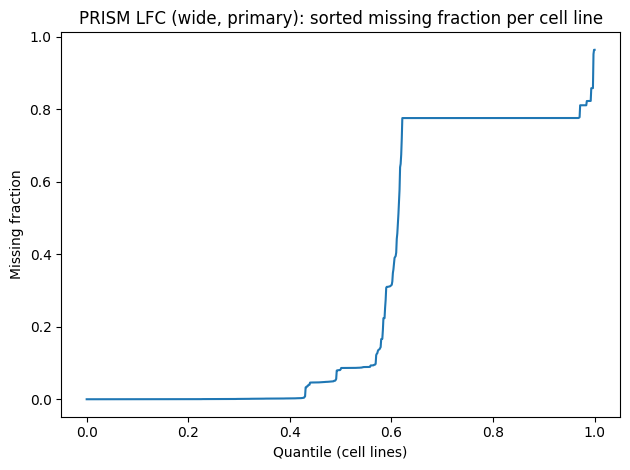

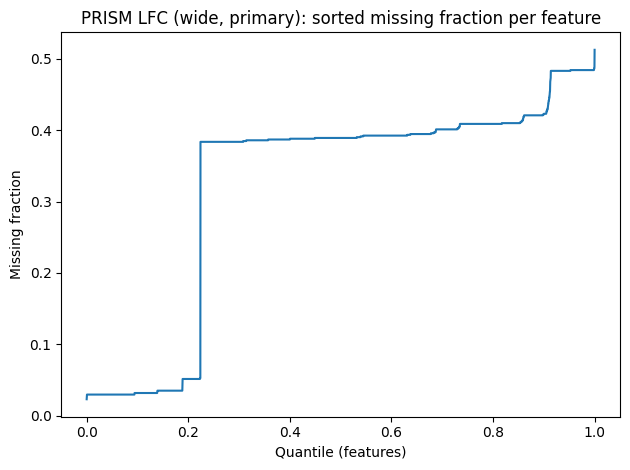

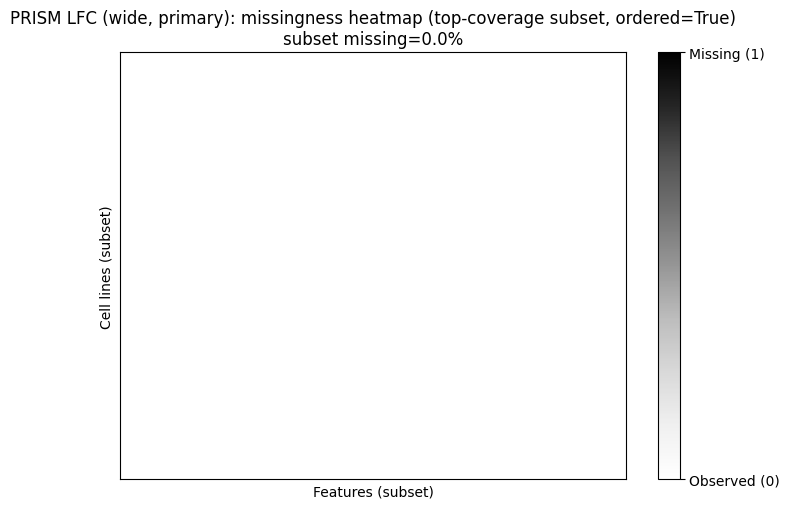

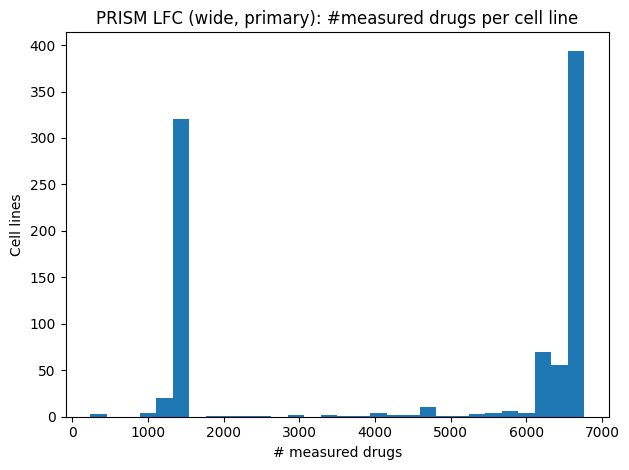

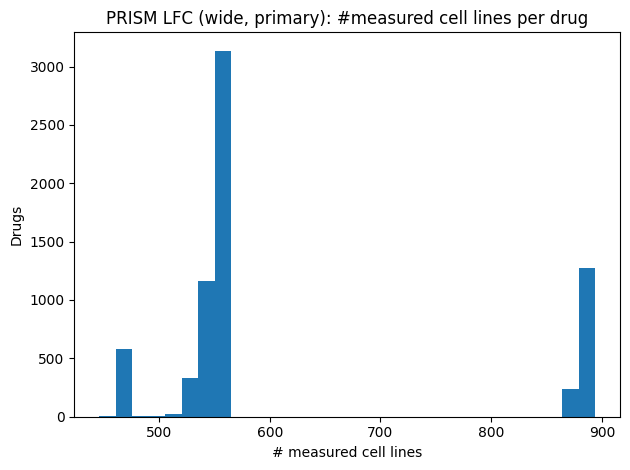

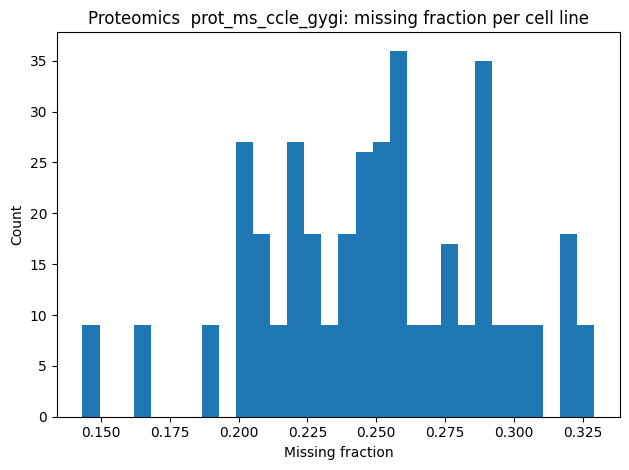

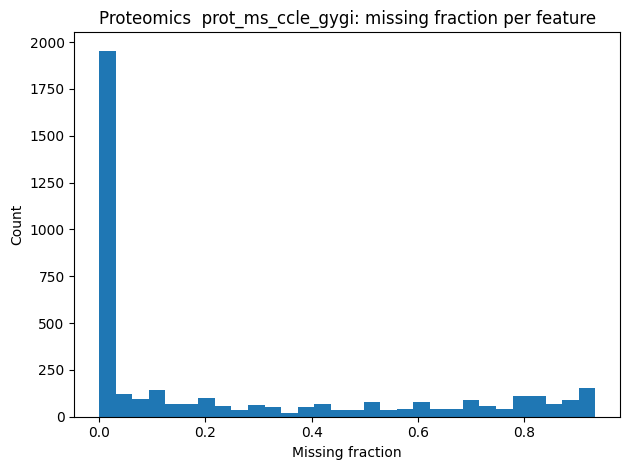

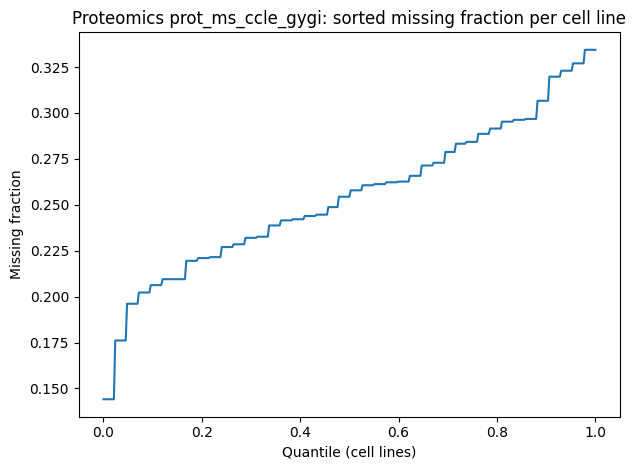

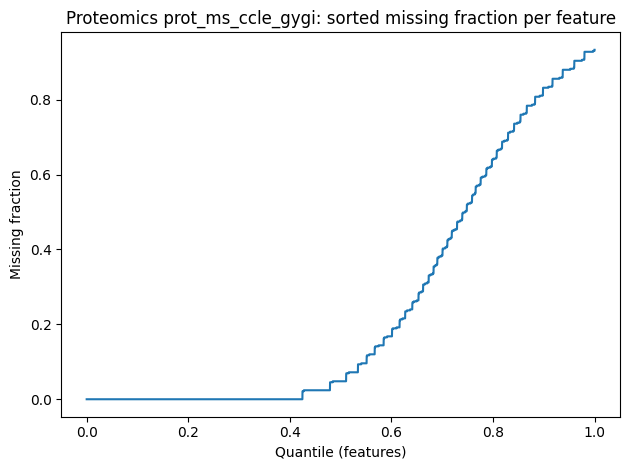

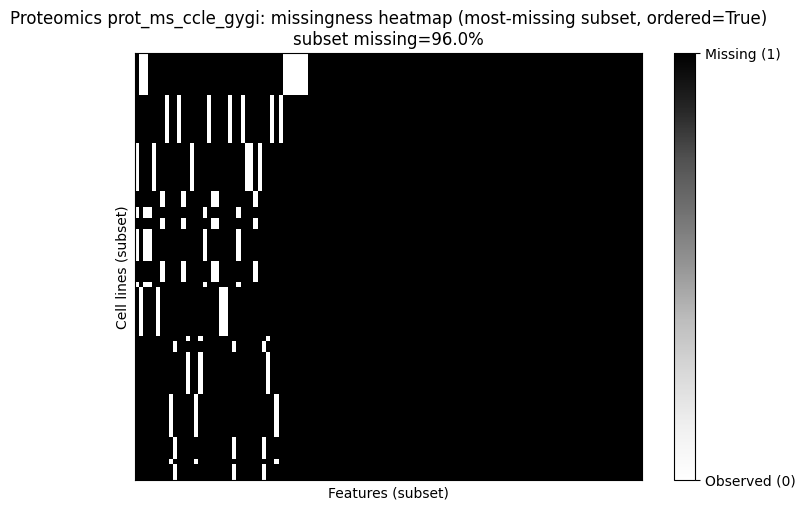

Top 10 features with most missing in Proteomics  prot_ms_ccle_gygi:


,missing_count
GCNT2,350
ORM2,350
GRID2IP,349
FAM151A,349
CHRD,349
ONECUT2,349
NEK8,349
NKX3-1,349
CPNE6,349
ZNF624,349


Top 10 cell lines with most missing in Proteomics  prot_ms_ccle_gygi:


,missing_count
depmap_id,
ACH-000097,3862
ACH-000395,3862
ACH-000012,3862
ACH-000929,3862
ACH-000649,3862
ACH-000842,3862
ACH-000601,3862
ACH-000805,3862
ACH-000383,3862


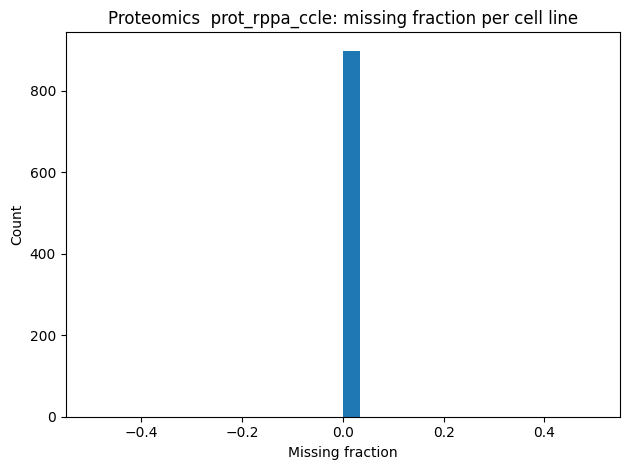

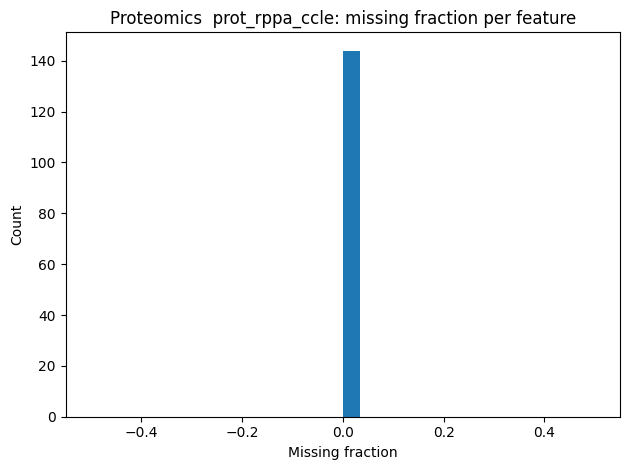

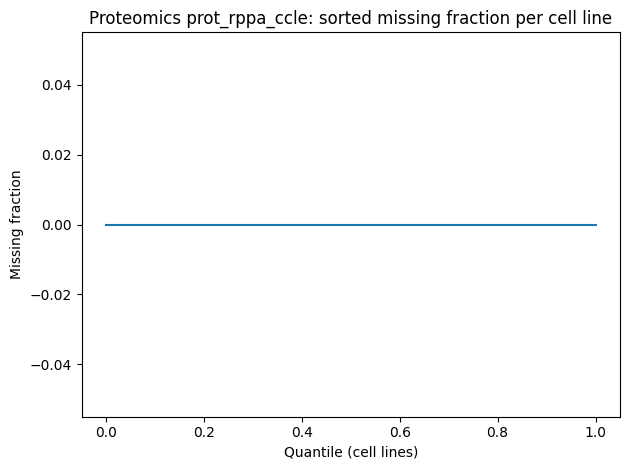

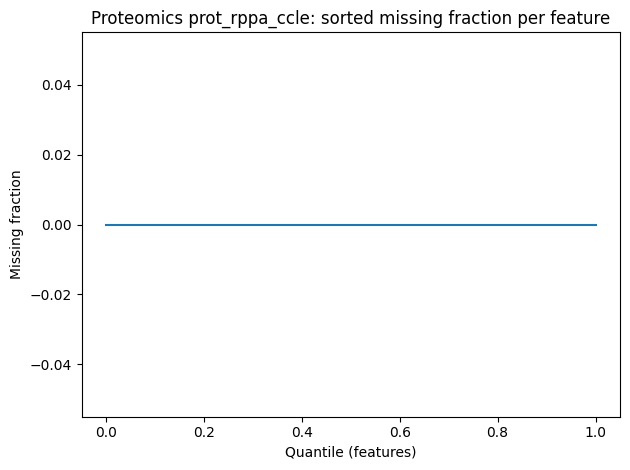

Top 10 features with most missing in Proteomics  prot_rppa_ccle:


,missing_count
O00418 (EEF2K),0
O00767 (SCD),0
O15151 (MDM4),0
O15327 (INPP4B),0
O60674 (JAK2),0
O95471 (CLDN7),0
O95661 (DIRAS3),0
O95863 (SNAI1),0
O96017 (CHEK2),0
O96020 (CCNE2),0


Top 10 cell lines with most missing in Proteomics  prot_rppa_ccle:


,missing_count
depmap_id,
ACH-000520,0
ACH-000973,0
ACH-000248,0
ACH-001016,0
ACH-000245,0
ACH-000402,0
ACH-000536,0
ACH-000927,0
ACH-000818,0


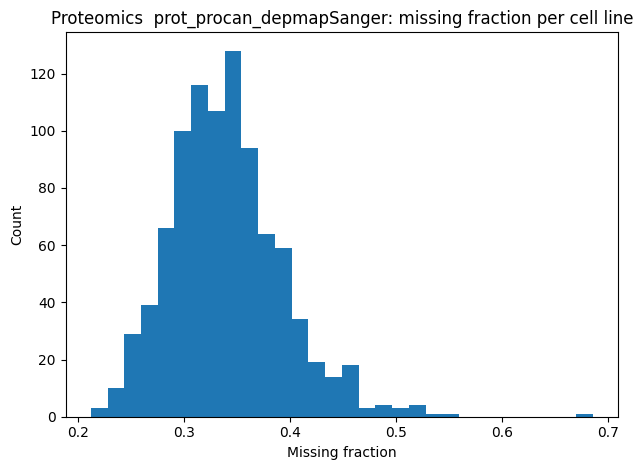

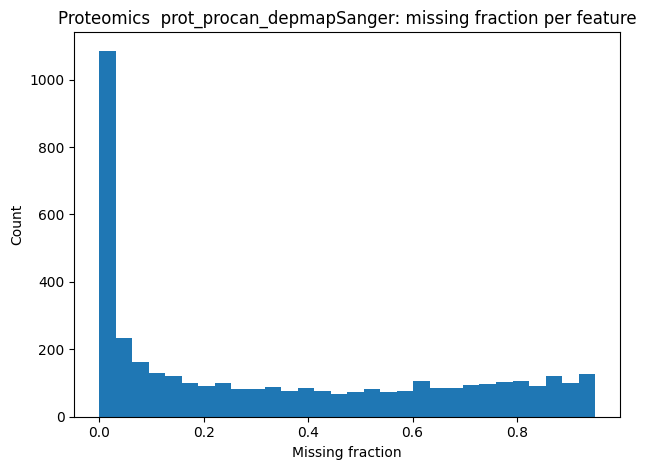

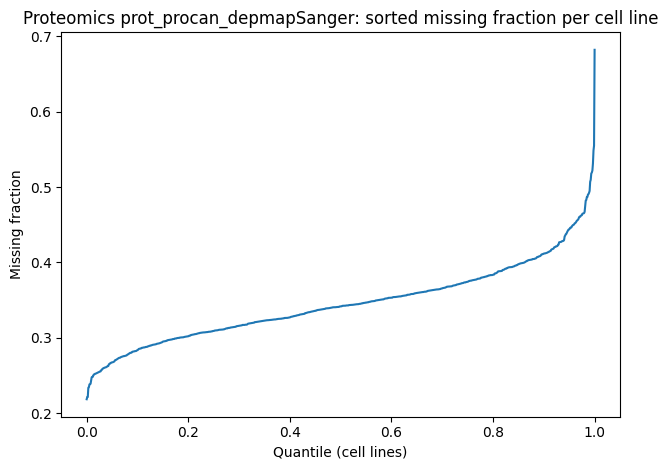

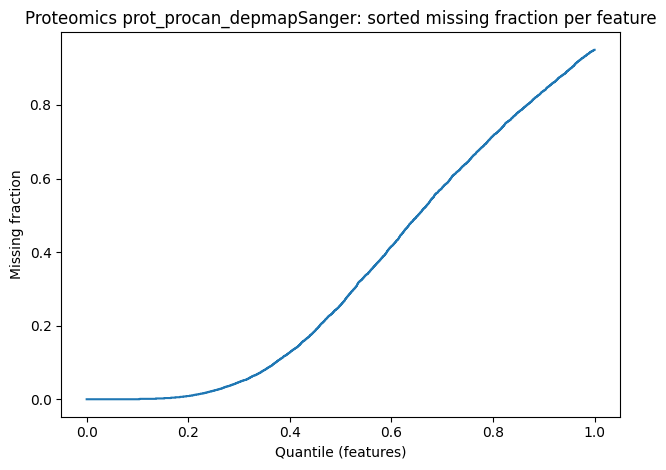

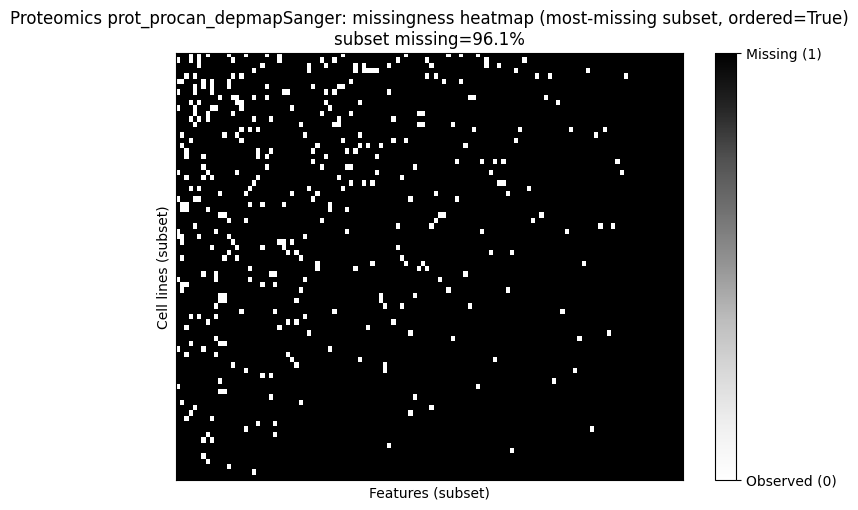

Top 10 features with most missing in Proteomics  prot_procan_depmapSanger:


,missing_count
symbol,
PCDH9,871
HPCAL4,871
HSD11B2,871
NIBAN3,871
BCL6,871
ALDOB,871
RASIP1,871
PRSS56,871
SEMA5B,871


Top 10 cell lines with most missing in Proteomics  prot_procan_depmapSanger:


,missing_count
depmap_id,
ACH-000362,5393
ACH-002186,4387
ACH-000547,4336
ACH-000794,4199
ACH-002212,4126
ACH-000936,4105
ACH-000002,4095
ACH-000905,4029
ACH-000218,4008


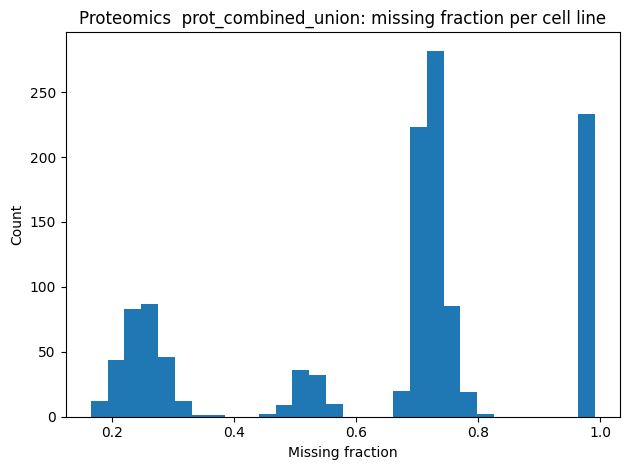

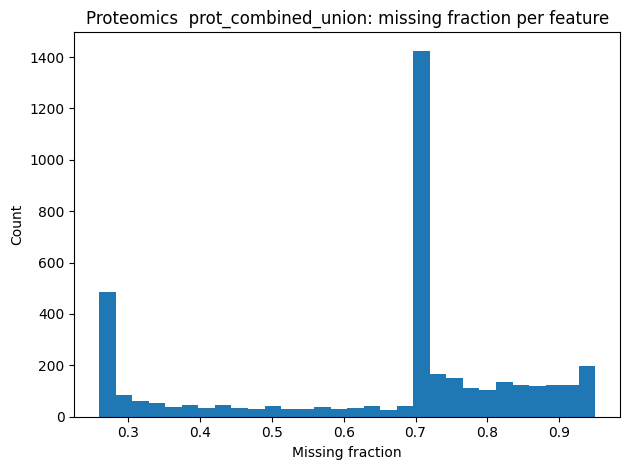

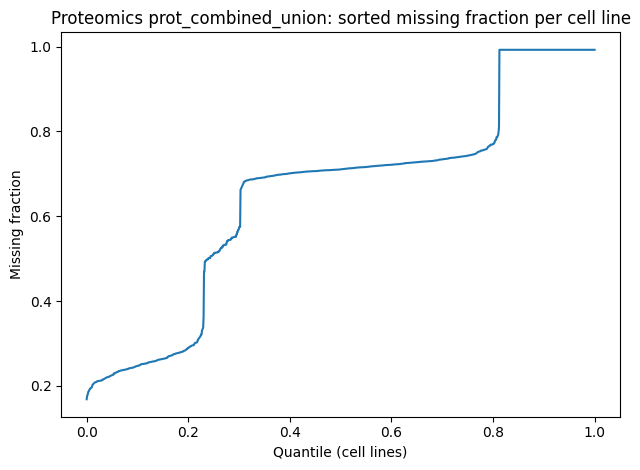

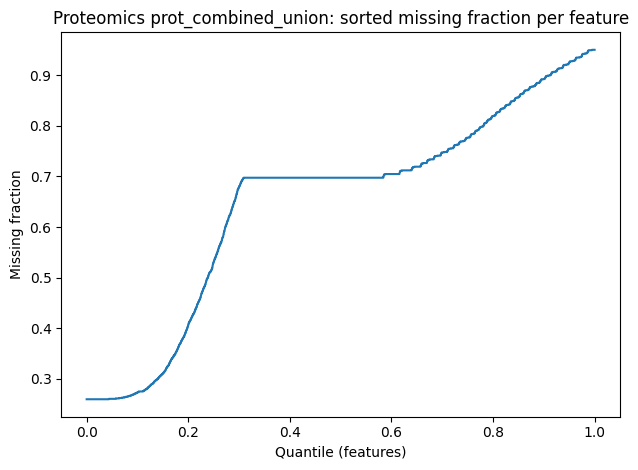

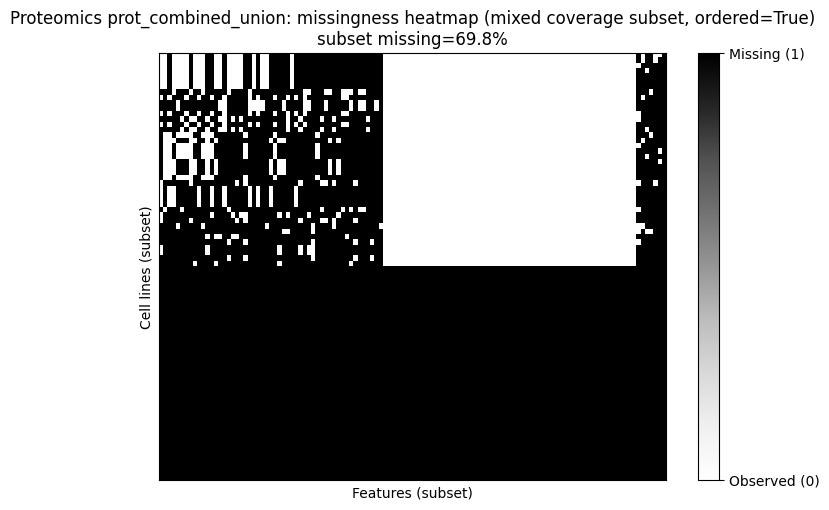

Top 10 features with most missing in Proteomics  prot_combined_union:


,missing_count
ms__TUBA8,1177
ms__TSPY10,1177
ms__CDKN2D,1177
ms__LRRN1,1177
ms__IGHG3,1177
ms__SLC45A2,1177
ms__RGPD2,1177
ms__NALCN,1177
ms__MT1E,1177
ms__UTP14C,1177


Top 10 cell lines with most missing in Proteomics  prot_combined_union:


,missing_count
depmap_id,
ACH-000131,18607
ACH-000122,18607
ACH-000214,18607
ACH-000224,18607
ACH-000194,18607
ACH-000801,18607
ACH-000725,18607
ACH-000731,18607
ACH-000310,18607


EDA: Proteomics mean-vs-missing (left-censoring proxy) 


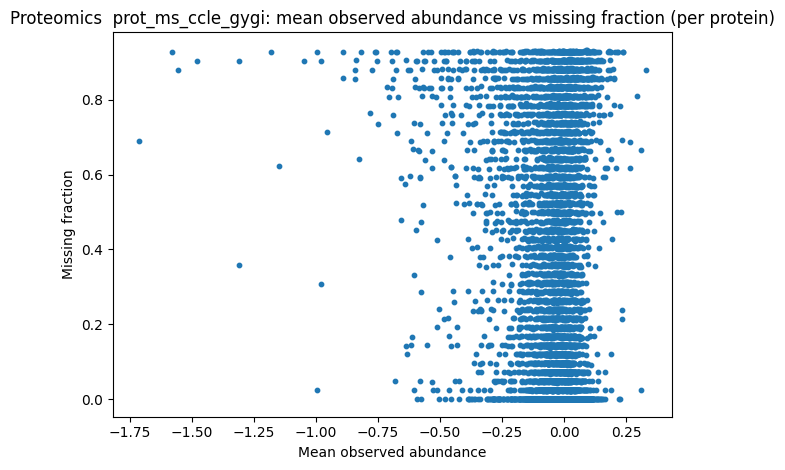

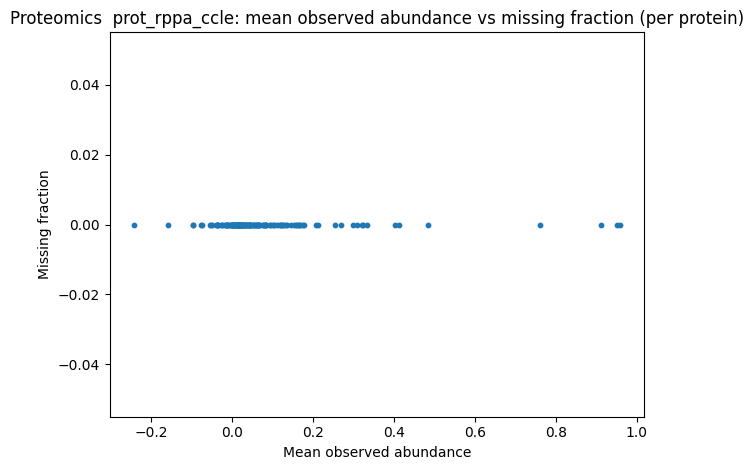

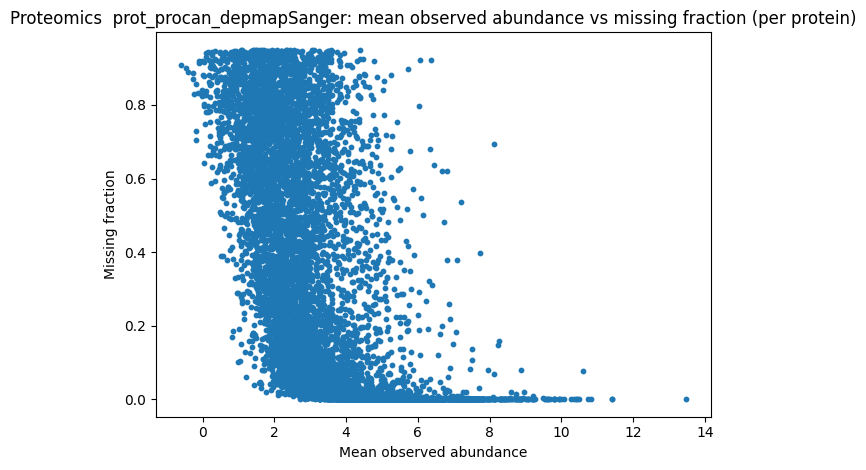

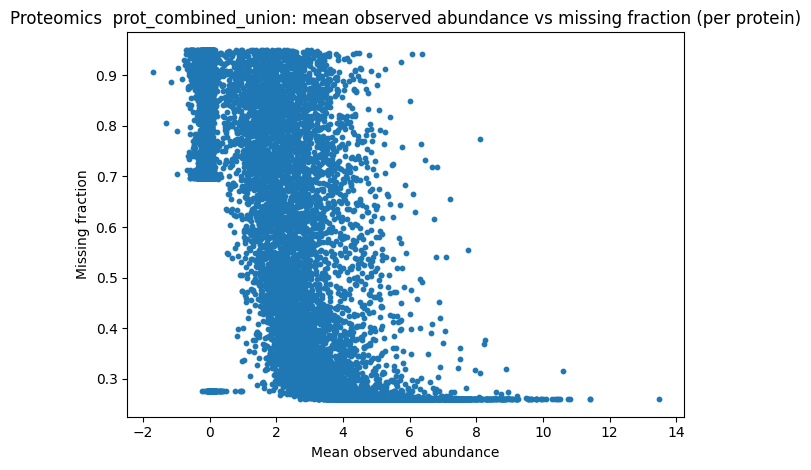

EDA: PRISM coverage 


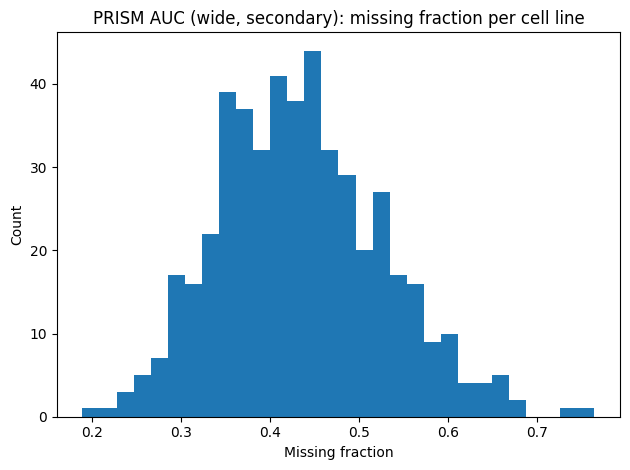

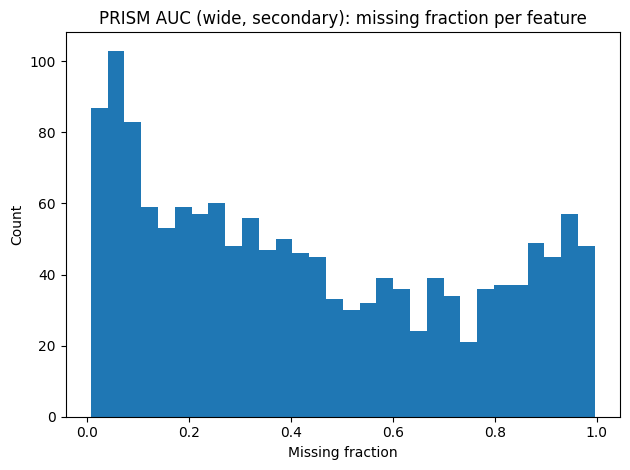

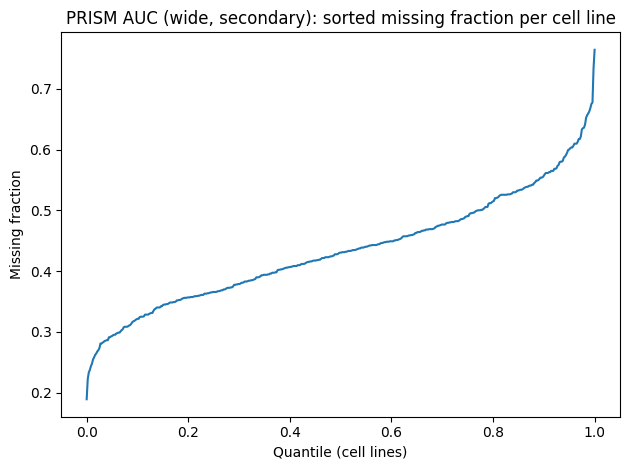

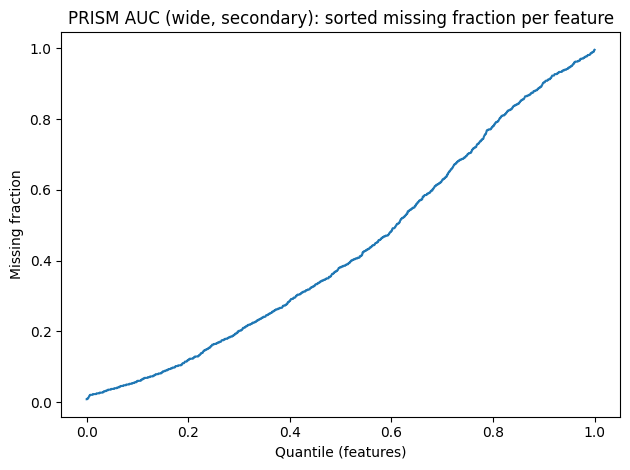

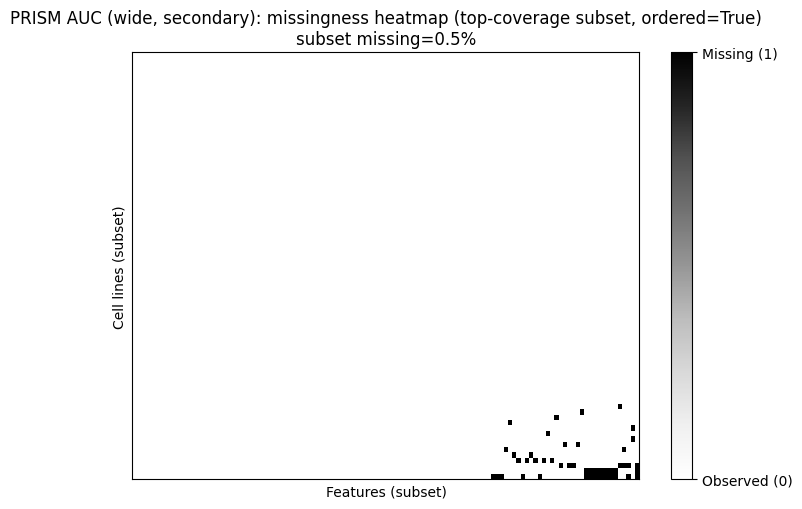

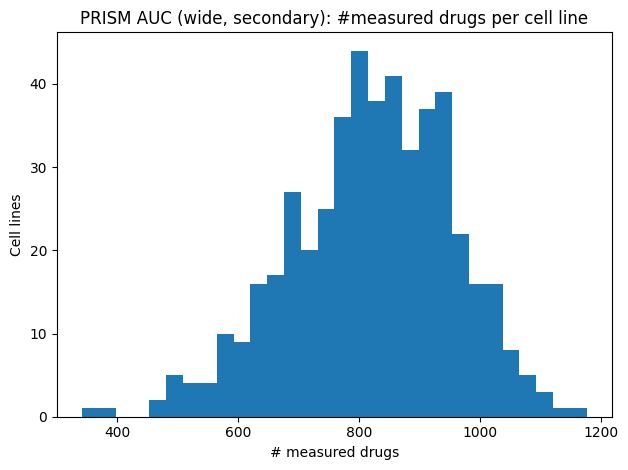

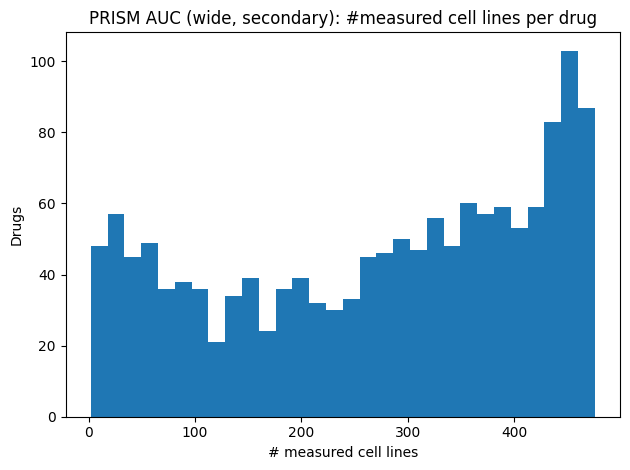

EDA: Lineage distribution (from DepMap metadata) 


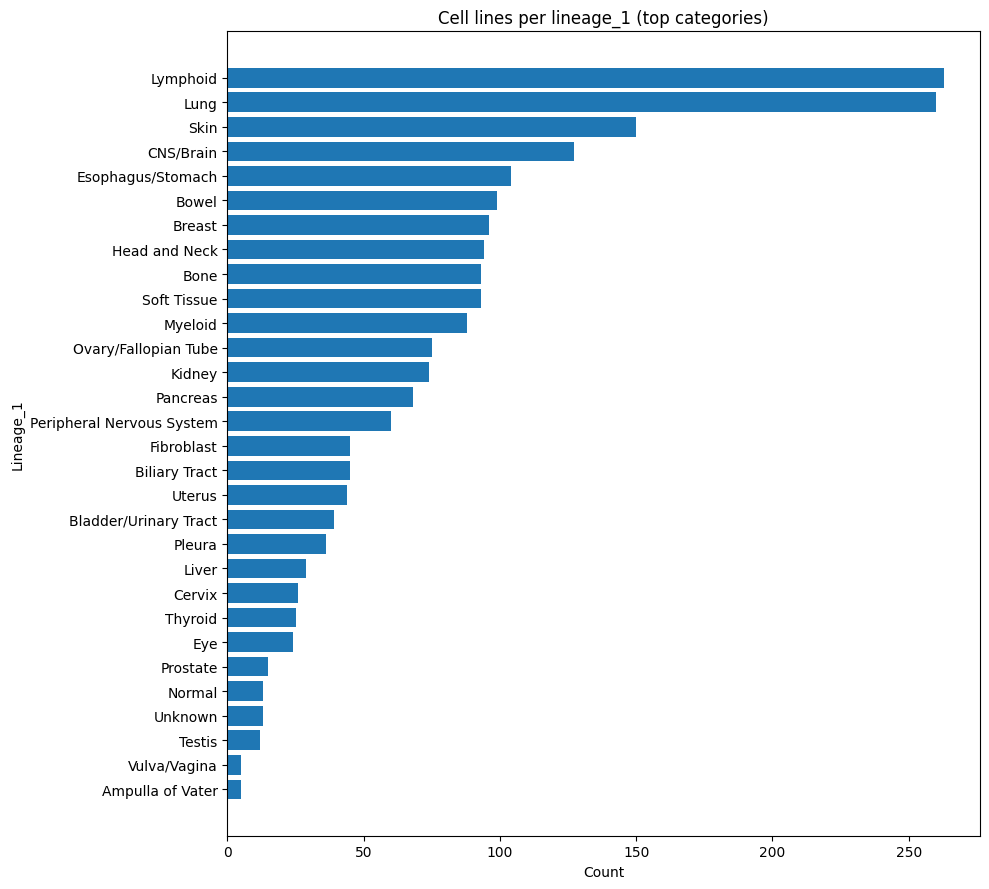

EDA: PCA sanity plots 


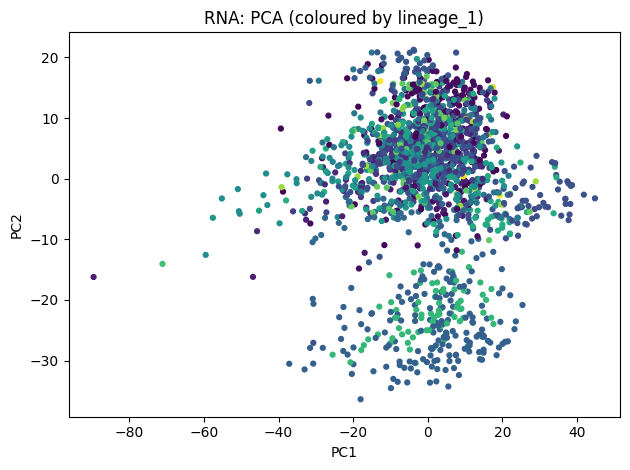

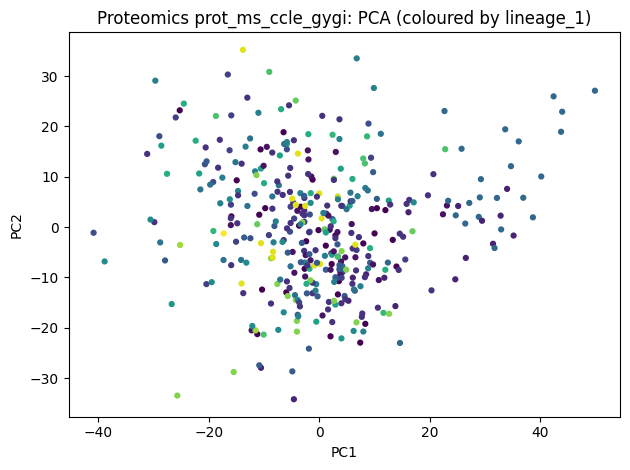

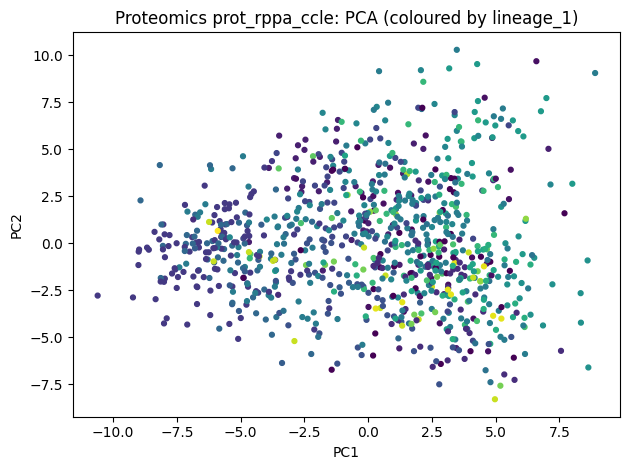

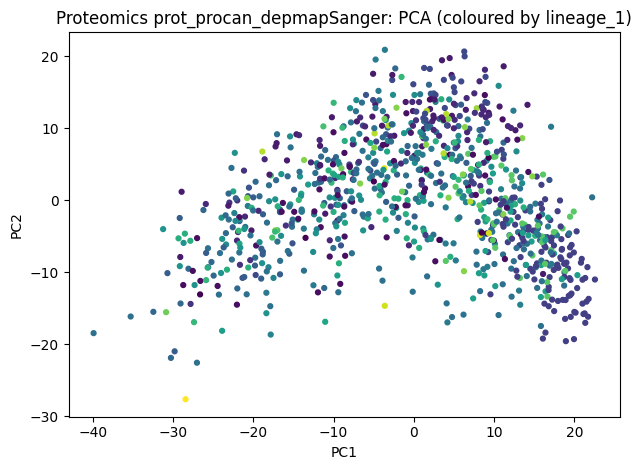

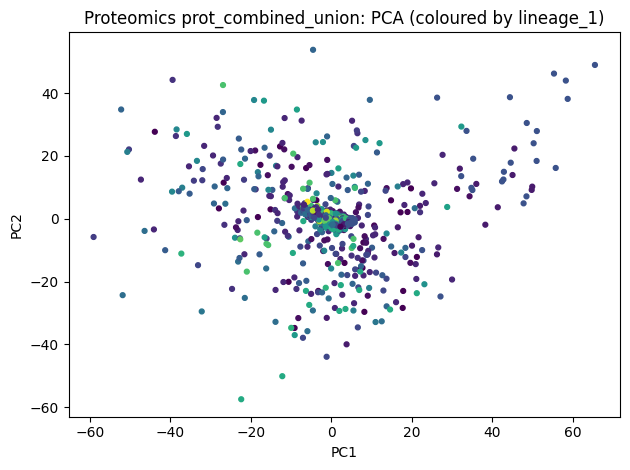

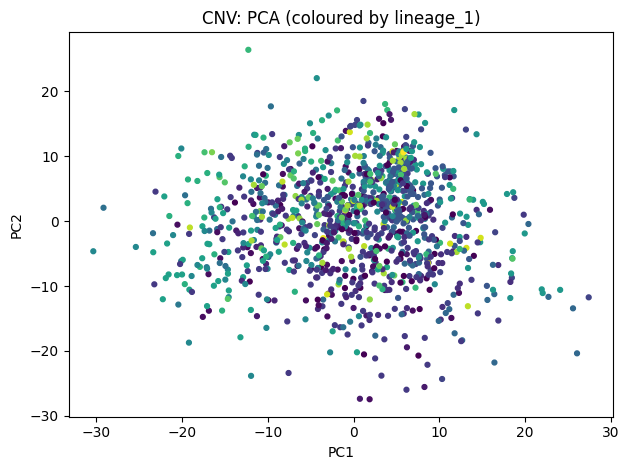

EDA (extra): PRISM value distributions


C:\Users\Owner\AppData\Local\Temp\ipykernel_31724\1342029110.py:326: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = prism_wide.stack(dropna=True)


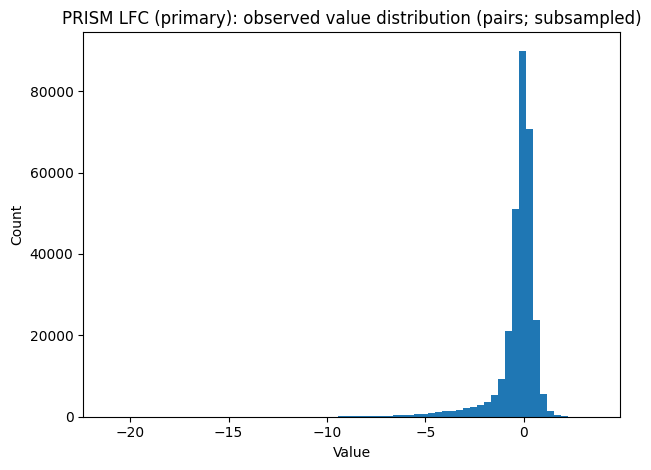

[PRISM LFC (primary)] wrote quantiles: artifacts\reports\notebook 1\prism_lfc_wide__value_quantiles.csv
[PRISM LFC (primary)] wrote per-drug summary: artifacts\reports\notebook 1\prism_lfc_wide__value_summary_by_drug.csv


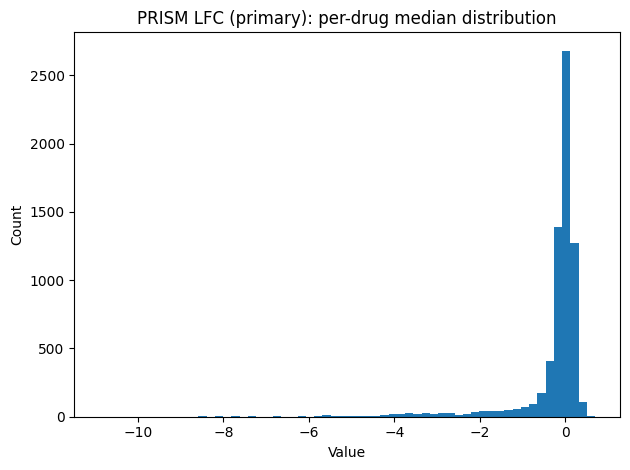

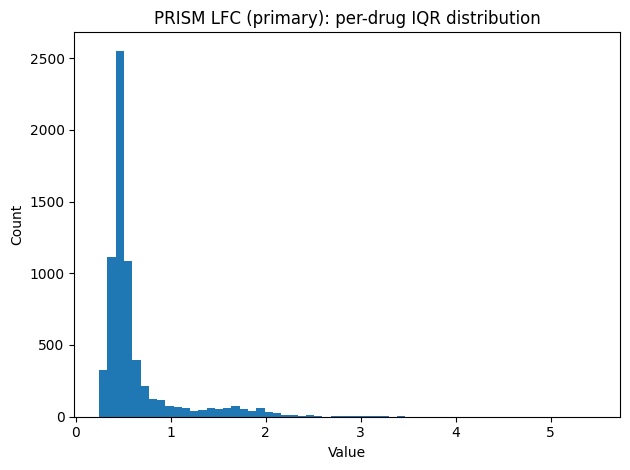

[PRISM LFC (primary)] wrote top-range drugs: artifacts\reports\notebook 1\prism_lfc_wide__top20_drugs_by_range.csv
[PRISM AUC (secondary)] wrote quantiles: artifacts\reports\notebook 1\prism_auc_wide__value_quantiles.csv
[PRISM AUC (secondary)] wrote per-drug summary: artifacts\reports\notebook 1\prism_auc_wide__value_summary_by_drug.csv


C:\Users\Owner\AppData\Local\Temp\ipykernel_31724\1342029110.py:326: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = prism_wide.stack(dropna=True)


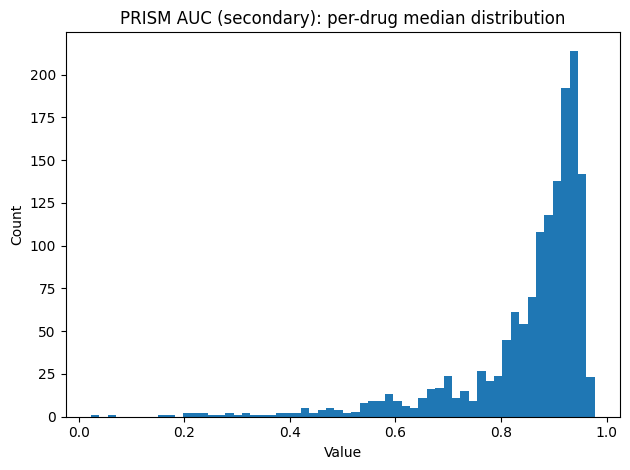

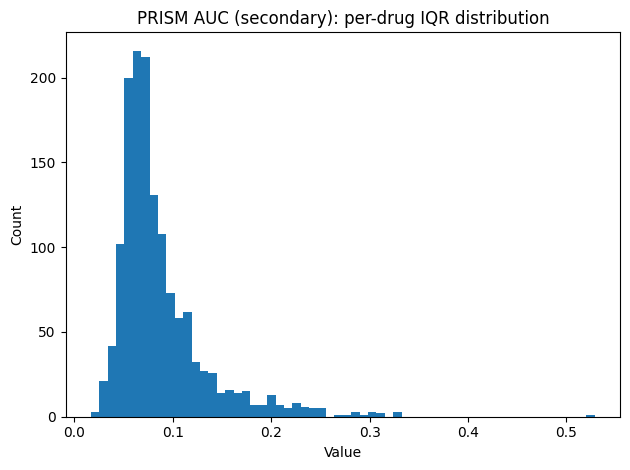

[PRISM AUC (secondary)] wrote top-range drugs: artifacts\reports\notebook 1\prism_auc_wide__top20_drugs_by_range.csv
EDA (extra): Proteomics value + coverage distributions


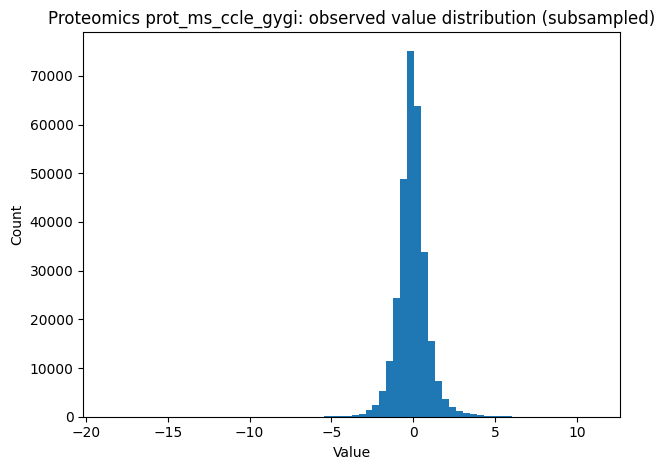

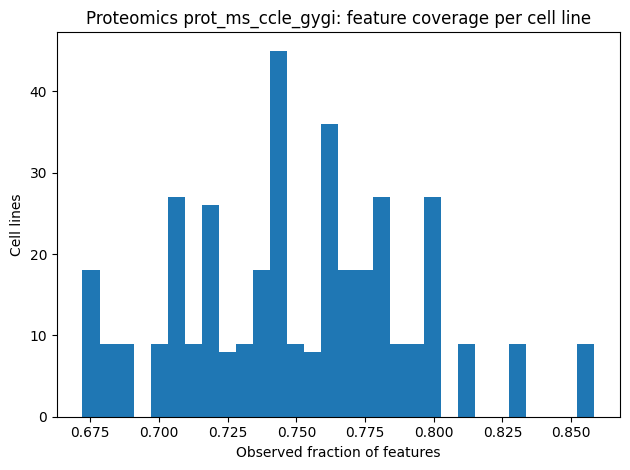

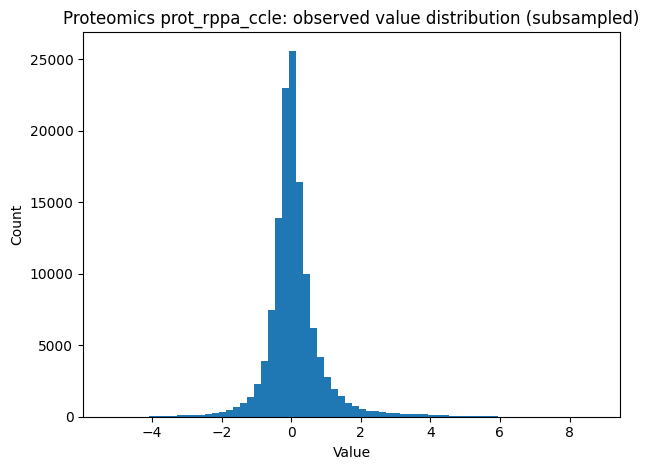

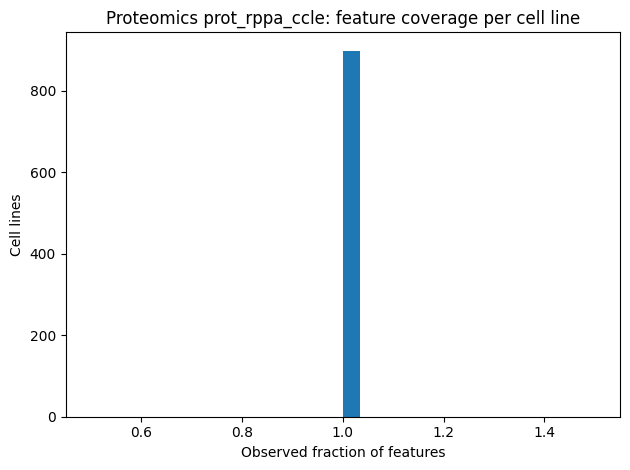

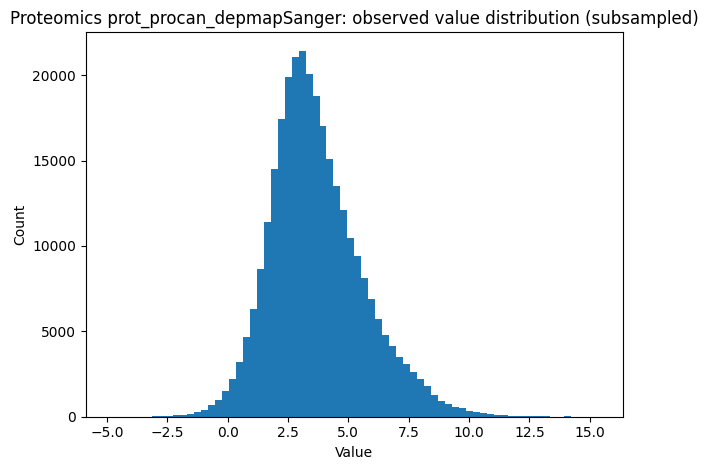

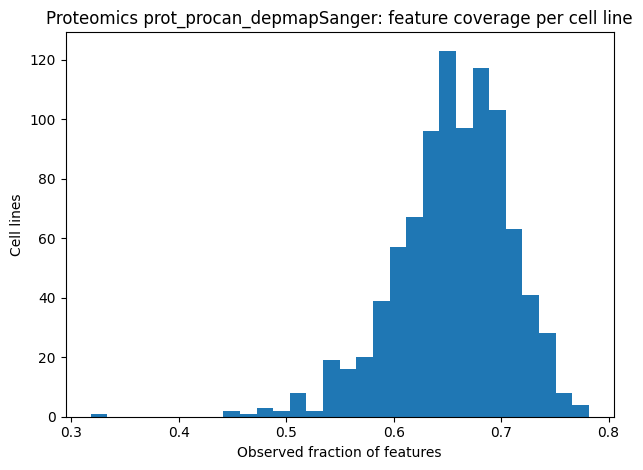

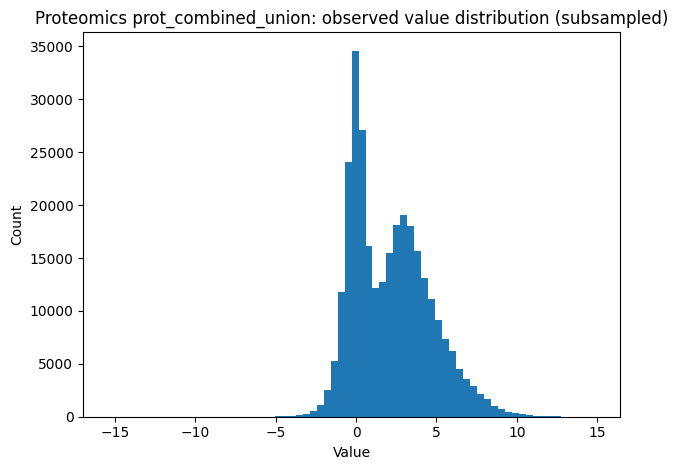

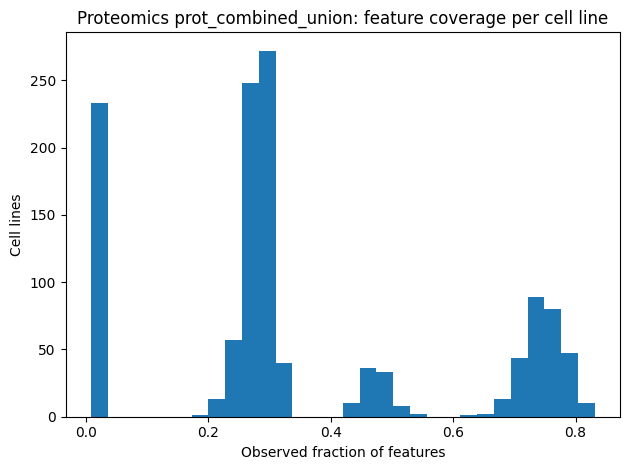

EDA (extra): Explicit overlap tables/plots
Saved: artifacts\reports\notebook 1\overlap__with_prism_lfc.csv


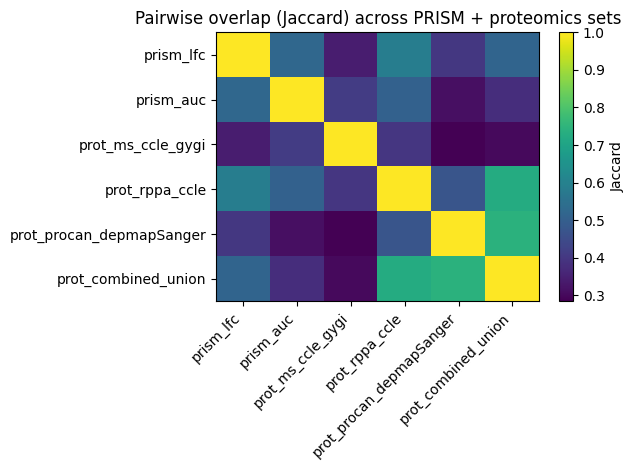

Saved: artifacts\reports\notebook 1\overlap__exact_intersections.csv
EDA (extra): Coverage vs lineage_1 (missingness entanglement check)
Saved: artifacts\reports\notebook 1\prism_lfc__measured_drugs_by_lineage1_box__summary.csv


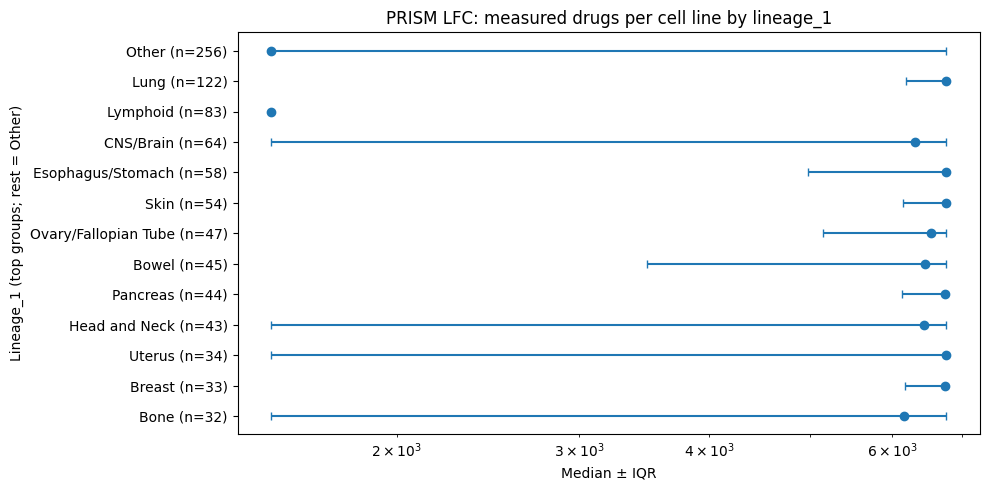

Saved: artifacts\reports\notebook 1\prism_lfc__missing_frac_by_lineage1_box__summary.csv


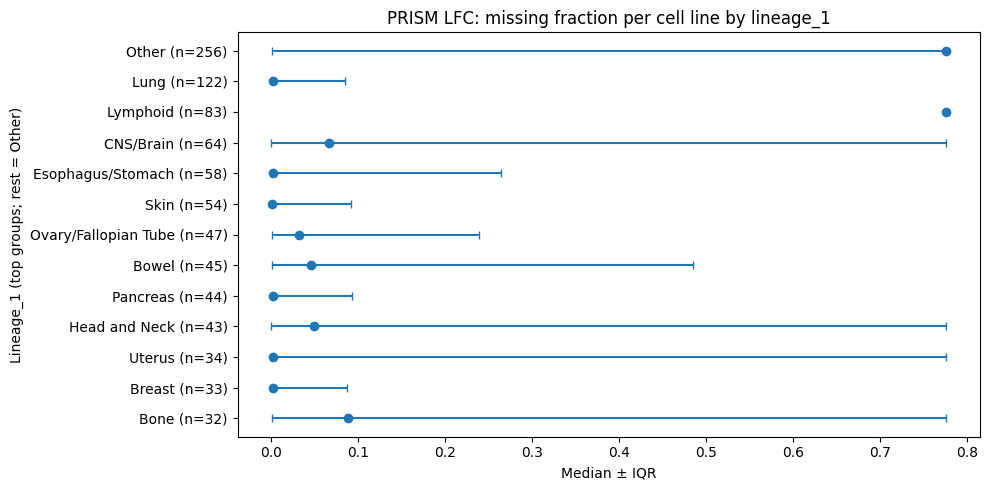

Saved: artifacts\reports\notebook 1\prot__prot_ms_ccle_gygi__coverage_by_lineage1_box__summary.csv


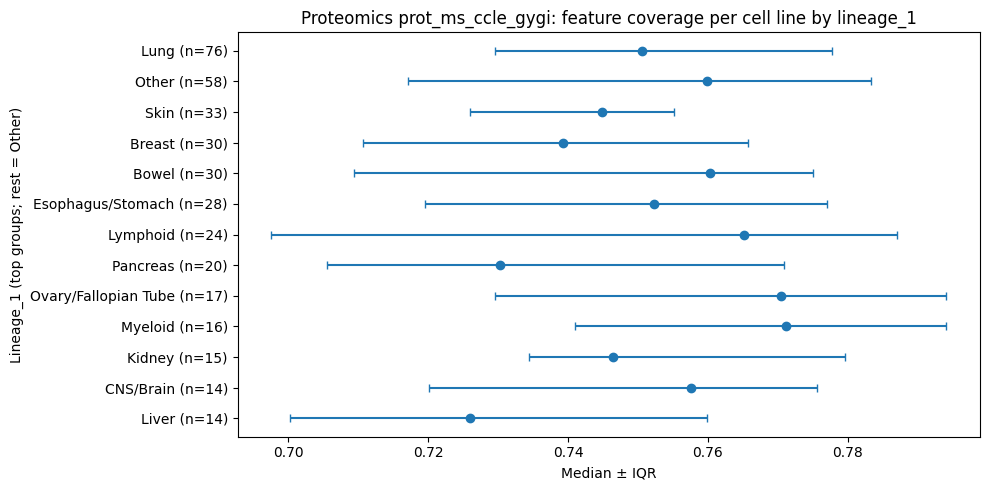

Saved: artifacts\reports\notebook 1\prot__prot_rppa_ccle__coverage_by_lineage1_box__summary.csv


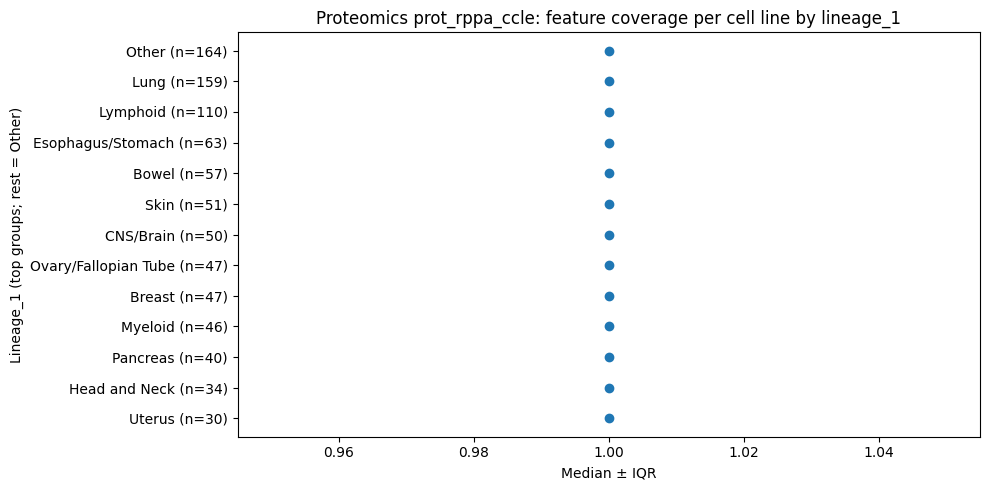

Saved: artifacts\reports\notebook 1\prot__prot_procan_depmapSanger__coverage_by_lineage1_box__summary.csv


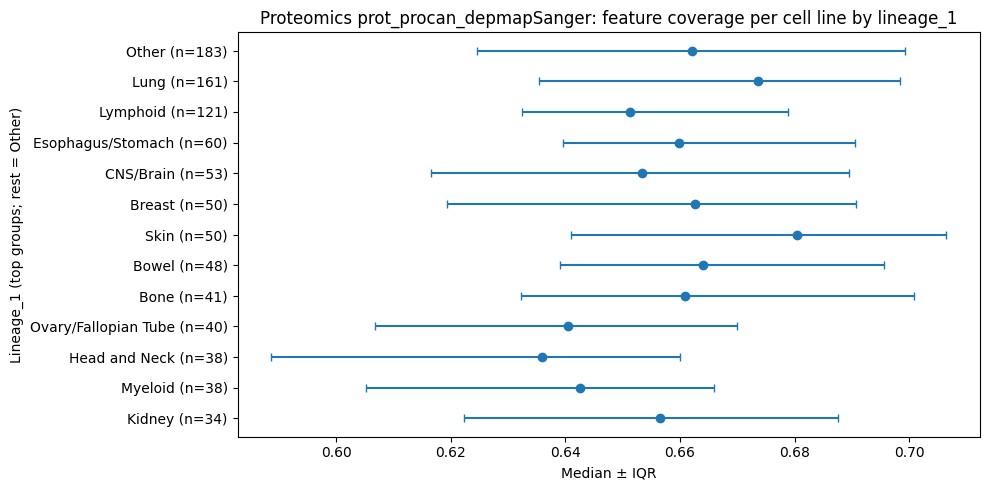

Saved: artifacts\reports\notebook 1\prot__prot_combined_union__coverage_by_lineage1_box__summary.csv


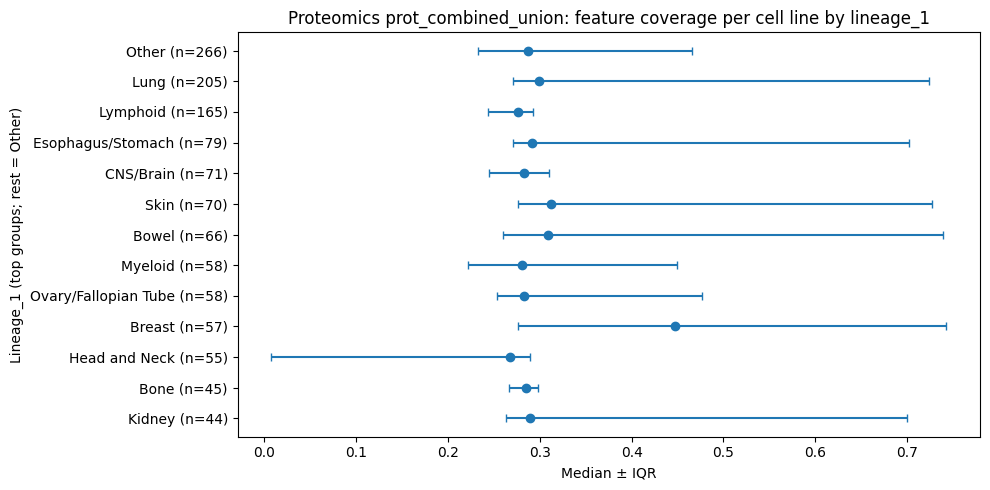

Saved EDA reports to: artifacts\reports\notebook 1


In [9]:
def showfig(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

def _maybe_subsample_cols(df: pd.DataFrame, max_cols: int):
    if df.shape[1] <= max_cols:
        return df
    cols = RNG.choice(df.columns, size=max_cols, replace=False)
    return df.loc[:, cols]

def plot_missingness_hist(df: pd.DataFrame, title: str, out_prefix: str, max_cols: int = 4000):
    X = _maybe_subsample_cols(df, max_cols=max_cols)

    row_frac = X.isna().mean(axis=1).values if X.shape[1] else np.array([])
    col_frac = X.isna().mean(axis=0).values if X.shape[0] else np.array([])

    plt.figure()
    plt.hist(row_frac, bins=30)
    plt.title(f"{title}: missing fraction per cell line")
    plt.xlabel("Missing fraction")
    plt.ylabel("Count")
    showfig(OUT_REPORTS / f"{out_prefix}__missing_rows_hist.png")

    plt.figure()
    plt.hist(col_frac, bins=30)
    plt.title(f"{title}: missing fraction per feature")
    plt.xlabel("Missing fraction")
    plt.ylabel("Count")
    showfig(OUT_REPORTS / f"{out_prefix}__missing_cols_hist.png")

def plot_missingness_rank_curves(df: pd.DataFrame, title: str, out_prefix: str, max_cols: int = 8000):
    X = _maybe_subsample_cols(df, max_cols=max_cols)
    if X.shape[0] == 0 or X.shape[1] == 0:
        print(f"[{title}] rank curves skipped (empty matrix).")
        return

    row_frac = X.isna().mean(axis=1).sort_values()
    col_frac = X.isna().mean(axis=0).sort_values()

    # Row curve
    plt.figure()
    xr = np.linspace(0, 1, row_frac.shape[0], endpoint=True)
    plt.plot(xr, row_frac.values)
    plt.title(f"{title}: sorted missing fraction per cell line")
    plt.xlabel("Quantile (cell lines)")
    plt.ylabel("Missing fraction")
    showfig(OUT_REPORTS / f"{out_prefix}__missing_rows_rankcurve.png")

    # Col curve
    plt.figure()
    xc = np.linspace(0, 1, col_frac.shape[0], endpoint=True)
    plt.plot(xc, col_frac.values)
    plt.title(f"{title}: sorted missing fraction per feature")
    plt.xlabel("Quantile (features)")
    plt.ylabel("Missing fraction")
    showfig(OUT_REPORTS / f"{out_prefix}__missing_cols_rankcurve.png")

def plot_missingness_heatmap_subset(
    df: pd.DataFrame,
    title: str,
    out_name: str,
    n_rows: int = 80,
    n_cols: int = 120,
    subset_mode: str = "random",   # "random" | "most_missing" | "least_missing" | "mixed" | "top_coverage"
    order_axes: bool = True,
    col_prefix_order: list[str] | None = None,  # e.g. ["ms__", "rppa__", "procan__"] for combined union
):
    """
    Missingness heatmap for a subset, but made interpretable:
    - subset_mode="top_coverage" is ideal for PRISM (shows densest block rather than noise).
    - subset_mode="mixed" shows both best + worst coverage in the same view.
    - order_axes=True sorts rows/cols by missingness inside the subset (reveals structure).
    - col_prefix_order groups columns by platform prefix before sorting (best for combined union).
    """
    if df.shape[0] == 0 or df.shape[1] == 0:
        print(f"[{title}] heatmap skipped (empty matrix).")
        return

    row_miss = df.isna().mean(axis=1)
    col_miss = df.isna().mean(axis=0)

    n_r = min(n_rows, df.shape[0])
    n_c = min(n_cols, df.shape[1])

    if subset_mode == "most_missing":
        row_idx = row_miss.sort_values(ascending=False).index[:n_r]
        col_idx = col_miss.sort_values(ascending=False).index[:n_c]
        subtitle = "most-missing subset"
    elif subset_mode == "least_missing":
        row_idx = row_miss.sort_values(ascending=True).index[:n_r]
        col_idx = col_miss.sort_values(ascending=True).index[:n_c]
        subtitle = "least-missing subset"
    elif subset_mode == "top_coverage":
        # same as least_missing, but semantically clearer for PRISM discussions
        row_idx = row_miss.sort_values(ascending=True).index[:n_r]
        col_idx = col_miss.sort_values(ascending=True).index[:n_c]
        subtitle = "top-coverage subset"
    elif subset_mode == "mixed":
        # half densest + half sparsest (helps show missingness regimes)
        n_r1 = n_r // 2
        n_r2 = n_r - n_r1
        n_c1 = n_c // 2
        n_c2 = n_c - n_c1
        row_idx = row_miss.sort_values().index[:n_r1].append(row_miss.sort_values(ascending=False).index[:n_r2])
        col_idx = col_miss.sort_values().index[:n_c1].append(col_miss.sort_values(ascending=False).index[:n_c2])
        subtitle = "mixed coverage subset"
    else:
        # random (reproducible via global RNG)
        row_idx = pd.Index(RNG.choice(df.index.to_numpy(), size=n_r, replace=False))
        col_idx = pd.Index(RNG.choice(df.columns.to_numpy(), size=n_c, replace=False))
        subtitle = "random subset"

    X = df.loc[row_idx, col_idx]

    # Optional: group columns by prefix (useful for prot_combined_union)
    if col_prefix_order is not None:
        cols = list(X.columns)
        ordered = []
        used = set()
        for pref in col_prefix_order:
            block = [c for c in cols if str(c).startswith(pref)]
            ordered.extend(block)
            used.update(block)
        ordered.extend([c for c in cols if c not in used])
        X = X.loc[:, ordered]

    if order_axes:
        row_order = X.isna().mean(axis=1).sort_values(ascending=True).index
    else:
        row_order = X.index

    if col_prefix_order is None:
        col_order = X.isna().mean(axis=0).sort_values(ascending=True).index
    else:
        # Preserve platform blocks, but sort *within each block* by missingness
        col_order_list = []
        used = set()

        for pref in col_prefix_order:
            block = [c for c in X.columns if str(c).startswith(pref)]
            if block:
                block_order = X[block].isna().mean(axis=0).sort_values(ascending=True).index.tolist()
                col_order_list.extend(block_order)
                used.update(block)

        # Any remaining columns (unexpected prefixes) go at the end, also sorted
        rest = [c for c in X.columns if c not in used]
        if rest:
            rest_order = X[rest].isna().mean(axis=0).sort_values(ascending=True).index.tolist()
            col_order_list.extend(rest_order)

        col_order = pd.Index(col_order_list)

    X = X.loc[row_order, col_order]

    M = X.isna().astype(np.uint8).to_numpy()  # 1 = missing, 0 = observed
    miss_pct = 100.0 * M.mean()

    plt.figure(figsize=(7.2, 5.2))
    plt.imshow(M, aspect="auto", interpolation="nearest", vmin=0, vmax=1, cmap="Greys")
    plt.title(f"{title}: missingness heatmap ({subtitle}, ordered={order_axes})\nsubset missing={miss_pct:.1f}%")
    plt.xlabel("Features (subset)")
    plt.ylabel("Cell lines (subset)")

    # Binary colourbar so it doesn't look like a continuous variable
    cbar = plt.colorbar(ticks=[0, 1])
    cbar.ax.set_yticklabels(["Observed (0)", "Missing (1)"])

    # Hide ticks (they’re not meaningful for subsets and they clutter the plot)
    plt.xticks([])
    plt.yticks([])

    showfig(OUT_REPORTS / out_name)

def show_top_missing(df: pd.DataFrame, name: str, n: int = 10):
    if df.shape[0] == 0 or df.shape[1] == 0:
        print(f"[{name}] skipped (empty matrix).")
        return
    col_missing = df.isna().sum(axis=0).sort_values(ascending=False).head(n)
    row_missing = df.isna().sum(axis=1).sort_values(ascending=False).head(n)

    print(f"Top {n} features with most missing in {name}:")
    display(col_missing.rename("missing_count").to_frame())

    print(f"Top {n} cell lines with most missing in {name}:")
    display(row_missing.rename("missing_count").to_frame())

def plot_proteomics_mean_vs_missing(prot: pd.DataFrame, title: str, out_name: str, max_features: int = 25000):
    if prot.shape[1] == 0:
        print(f"[{title}] skipped (no features).")
        return

    X = _maybe_subsample_cols(prot, max_cols=max_features)
    miss_frac = X.isna().mean(axis=0)
    mean_obs = X.mean(axis=0, skipna=True)

    mask = mean_obs.notna()
    x = mean_obs[mask].values
    y = miss_frac[mask].values

    plt.figure()
    plt.scatter(x, y, s=10)
    plt.title(f"{title}: mean observed abundance vs missing fraction (per protein)")
    plt.xlabel("Mean observed abundance")
    plt.ylabel("Missing fraction")
    showfig(OUT_REPORTS / out_name)

def plot_prism_coverage(prism_wide: pd.DataFrame, title: str, out_prefix: str):
    if prism_wide.shape[1] == 0:
        print(f"[{title}] skipped (no compounds).")
        return
    per_line = prism_wide.notna().sum(axis=1)
    per_drug = prism_wide.notna().sum(axis=0)

    plt.figure()
    plt.hist(per_line.values, bins=30)
    plt.title(f"{title}: #measured drugs per cell line")
    plt.xlabel("# measured drugs")
    plt.ylabel("Cell lines")
    showfig(OUT_REPORTS / f"{out_prefix}__measured_drugs_per_cellline_hist.png")

    plt.figure()
    plt.hist(per_drug.values, bins=30)
    plt.title(f"{title}: #measured cell lines per drug")
    plt.xlabel("# measured cell lines")
    plt.ylabel("Drugs")
    showfig(OUT_REPORTS / f"{out_prefix}__measured_celllines_per_drug_hist.png")

    # Also save quick coverage tables (top/bottom)
    top_drugs = per_drug.sort_values(ascending=False).head(20).rename("n_cell_lines").to_frame()
    low_drugs = per_drug.sort_values(ascending=True).head(20).rename("n_cell_lines").to_frame()
    top_lines = per_line.sort_values(ascending=False).head(20).rename("n_drugs").to_frame()
    low_lines = per_line.sort_values(ascending=True).head(20).rename("n_drugs").to_frame()

    top_drugs.to_csv(OUT_REPORTS / f"{out_prefix}__top20_drugs_by_coverage.csv")
    low_drugs.to_csv(OUT_REPORTS / f"{out_prefix}__bottom20_drugs_by_coverage.csv")
    top_lines.to_csv(OUT_REPORTS / f"{out_prefix}__top20_lines_by_coverage.csv")
    low_lines.to_csv(OUT_REPORTS / f"{out_prefix}__bottom20_lines_by_coverage.csv")

def plot_lineage_counts(meta: pd.DataFrame, out_name: str, top_k: int = 30):
    if meta is None or "lineage_1" not in meta.columns:
        print("[lineage] skipped (no lineage_1 in metadata).")
        return

    counts = meta["lineage_1"].astype("string").fillna("Unknown").value_counts().head(top_k)

    # Horizontal bar chart so the lineage names are readable
    counts = counts.sort_values(ascending=True)

    plt.figure(figsize=(10, max(4, int(0.28 * len(counts) + 1))))
    plt.barh(range(len(counts)), counts.values)
    plt.yticks(range(len(counts)), counts.index.tolist())
    plt.title("Cell lines per lineage_1 (top categories)")
    plt.xlabel("Count")
    plt.ylabel("Lineage_1")
    showfig(OUT_REPORTS / out_name)

def quick_pca(df: pd.DataFrame, meta: pd.DataFrame, title: str, out_name: str, n_features: int = 2000):
    X = df
    if X.shape[1] > n_features:
        cols = RNG.choice(X.columns, size=n_features, replace=False)
        X = X[cols]

    # Drop features that are entirely missing
    X = X.loc[:, X.notna().any(axis=0)]
    if X.shape[1] < 2:
        print(f"[{title}] PCA skipped (insufficient usable features).")
        return

    X_imp = SimpleImputer(strategy="median").fit_transform(X.values)
    X_std = StandardScaler(with_mean=True, with_std=True).fit_transform(X_imp)
    emb = PCA(n_components=2, random_state=0).fit_transform(X_std)

    plt.figure()
    if meta is not None and "lineage_1" in meta.columns:
        codes, _ = pd.factorize(meta.loc[X.index, "lineage_1"])
        plt.scatter(emb[:, 0], emb[:, 1], c=codes, s=12)
        plt.title(f"{title}: PCA (coloured by lineage_1)")
    else:
        plt.scatter(emb[:, 0], emb[:, 1], s=12)
        plt.title(f"{title}: PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    showfig(OUT_REPORTS / out_name)


def _sample_values(values: np.ndarray, max_n: int = 250_000) -> np.ndarray:
    """Subsample 1D numpy array (reproducible via global RNG) for plotting speed."""
    values = values[np.isfinite(values)]
    if values.size <= max_n:
        return values
    idx = RNG.choice(values.size, size=max_n, replace=False)
    return values[idx]


def plot_value_hist(values: np.ndarray, title: str, out_name: str, bins: int = 60, max_n: int = 250_000):
    """Histogram of observed values (subsampled)."""
    v = _sample_values(np.asarray(values, dtype=float), max_n=max_n)
    if v.size == 0:
        print(f"[{title}] value histogram skipped (no finite values).")
        return
    plt.figure()
    plt.hist(v, bins=bins)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Count")
    showfig(OUT_REPORTS / out_name)


def prism_value_diagnostics(prism_wide: pd.DataFrame, metric: str, out_prefix: str, max_pairs: int = 300_000, plot_pairs_hist: bool = True):
    """
    PRISM value diagnostics:
    - overall value histogram (stacked pairs)
    - per-drug summary table (CSV)
    - histograms of per-drug medians and IQRs
    - top-20 drugs by range (CSV) to spot extreme tails/outliers
    """
    if prism_wide is None or prism_wide.shape[1] == 0:
        print(f"[PRISM {metric}] skipped (no compounds).")
        return

    # Overall stacked values (pairs)
    stacked = prism_wide.stack(dropna=True)
    all_vals = stacked.to_numpy(dtype=float)
    if plot_pairs_hist:
        plot_value_hist(
            all_vals,
            title=f"PRISM {metric}: observed value distribution (pairs; subsampled)",
            out_name=f"{out_prefix}__value_hist_pairs.png",
            bins=70,
            max_n=max_pairs,
        )

    # Overall quantiles (saved to CSV for later reporting)
    q = pd.Series(all_vals).quantile([0.001, 0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99, 0.999]).rename("value")
    q.to_frame().to_csv(OUT_REPORTS / f"{out_prefix}__value_quantiles.csv")
    print(f"[PRISM {metric}] wrote quantiles:", OUT_REPORTS / f"{out_prefix}__value_quantiles.csv")

    # Per-drug summaries
    per_drug = pd.DataFrame(index=prism_wide.columns.astype(str))
    per_drug["n_measured"] = prism_wide.notna().sum(axis=0).astype(int)
    per_drug["mean"] = prism_wide.mean(axis=0, skipna=True)
    per_drug["std"] = prism_wide.std(axis=0, skipna=True)
    per_drug["median"] = prism_wide.median(axis=0, skipna=True)
    per_drug["q25"] = prism_wide.quantile(0.25, axis=0, interpolation="linear")
    per_drug["q75"] = prism_wide.quantile(0.75, axis=0, interpolation="linear")
    per_drug["iqr"] = per_drug["q75"] - per_drug["q25"]
    per_drug["min"] = prism_wide.min(axis=0, skipna=True)
    per_drug["max"] = prism_wide.max(axis=0, skipna=True)
    per_drug["range"] = per_drug["max"] - per_drug["min"]

    per_drug = per_drug.sort_values(["n_measured", "range"], ascending=[False, False])
    per_drug_path = OUT_REPORTS / f"{out_prefix}__value_summary_by_drug.csv"
    per_drug.to_csv(per_drug_path)
    print(f"[PRISM {metric}] wrote per-drug summary:", per_drug_path)

    # Per-drug median and IQR distributions (quick sanity on scale / tails)
    plot_value_hist(
        per_drug["median"].to_numpy(dtype=float),
        title=f"PRISM {metric}: per-drug median distribution",
        out_name=f"{out_prefix}__per_drug_median_hist.png",
        bins=60,
        max_n=200_000,
    )
    plot_value_hist(
        per_drug["iqr"].to_numpy(dtype=float),
        title=f"PRISM {metric}: per-drug IQR distribution",
        out_name=f"{out_prefix}__per_drug_iqr_hist.png",
        bins=60,
        max_n=200_000,
    )

    # Top-20 drugs with largest range (often highlights outliers/heavy tails)
    top_range = per_drug.head(20)
    top_range.to_csv(OUT_REPORTS / f"{out_prefix}__top20_drugs_by_range.csv")
    print(f"[PRISM {metric}] wrote top-range drugs:", OUT_REPORTS / f"{out_prefix}__top20_drugs_by_range.csv")


def proteomics_value_diagnostics(prot: pd.DataFrame, arm: str, out_prefix: str, max_vals: int = 300_000):
    """
    Proteomics value diagnostics:
    - observed value histogram (flattened, subsampled)
    - per-cell-line coverage histogram (fraction observed per cell line)
    """
    if prot is None or prot.shape[1] == 0 or prot.shape[0] == 0:
        print(f"[PROT {arm}] skipped (empty).")
        return

    # Flatten observed values
    vals = prot.to_numpy(dtype=float).ravel()
    vals = vals[np.isfinite(vals)]
    plot_value_hist(
        vals,
        title=f"Proteomics {arm}: observed value distribution (subsampled)",
        out_name=f"{out_prefix}__observed_value_hist.png",
        bins=70,
        max_n=max_vals,
    )

    # Coverage per cell line (more intuitive than missing fraction for some discussions)
    cov = prot.notna().mean(axis=1).to_numpy(dtype=float)
    plt.figure()
    plt.hist(cov, bins=30)
    plt.title(f"Proteomics {arm}: feature coverage per cell line")
    plt.xlabel("Observed fraction of features")
    plt.ylabel("Cell lines")
    showfig(OUT_REPORTS / f"{out_prefix}__coverage_per_cellline_hist.png")


def compute_overlap_reports(
    prism_lfc: pd.DataFrame,
    prism_auc: pd.DataFrame,
    proteomics_arms: dict,
    plot_counts_heatmap: bool = False,
    plot_top_exact_intersections: bool = False,
):
    """
    Overlap diagnostics:
    - overlap counts with PRISM LFC (primary) for each arm
    - pairwise overlap/jaccard between all sets (LFC, AUC, arms)
    - exact intersection counts saved as CSV (UpSet-like table), but plotting is optional
    """
    sets = {
        "prism_lfc": set(map(str, prism_lfc.index)) if prism_lfc is not None else set(),
        "prism_auc": set(map(str, prism_auc.index)) if prism_auc is not None else set(),
    }
    for arm, df in proteomics_arms.items():
        sets[arm] = set(map(str, df.index)) if df is not None else set()

    # Overlap with PRISM LFC (table)
    lfc_set = sets["prism_lfc"]
    rows = []
    for name, s in sets.items():
        if name == "prism_lfc":
            continue
        inter = len(lfc_set & s)
        rows.append({
            "set": name,
            "n_prism_lfc": len(lfc_set),
            "n_set": len(s),
            "n_intersection": inter,
            "jaccard": (inter / len(lfc_set | s)) if (len(lfc_set | s) > 0) else 0.0
        })
    overlap_lfc_df = pd.DataFrame(rows).sort_values("n_intersection", ascending=False)
    overlap_lfc_path = OUT_REPORTS / "overlap__with_prism_lfc.csv"
    overlap_lfc_df.to_csv(overlap_lfc_path, index=False)
    print("Saved:", overlap_lfc_path)

    # Pairwise matrices (counts + jaccard)
    names = list(sets.keys())
    n = len(names)
    counts = np.zeros((n, n), dtype=int)
    jacc = np.zeros((n, n), dtype=float)

    for i, a in enumerate(names):
        for j, b in enumerate(names):
            inter = len(sets[a] & sets[b])
            uni = len(sets[a] | sets[b])
            counts[i, j] = inter
            jacc[i, j] = (inter / uni) if uni else 0.0

    counts_df = pd.DataFrame(counts, index=names, columns=names)
    jacc_df = pd.DataFrame(jacc, index=names, columns=names)

    counts_df.to_csv(OUT_REPORTS / "overlap__pairwise_intersection_counts.csv")
    jacc_df.to_csv(OUT_REPORTS / "overlap__pairwise_jaccard.csv")

    # Plot ONLY the Jaccard heatmap (more interpretable), counts heatmap is optional
    plt.figure()
    plt.imshow(jacc, aspect="auto")
    plt.title("Pairwise overlap (Jaccard) across PRISM + proteomics sets")
    plt.xticks(range(n), names, rotation=45, ha="right")
    plt.yticks(range(n), names)
    plt.colorbar(label="Jaccard")
    showfig(OUT_REPORTS / "overlap__pairwise_jaccard_heatmap.png")

    if plot_counts_heatmap:
        plt.figure()
        plt.imshow(counts, aspect="auto")
        plt.title("Pairwise overlap (intersection counts) across PRISM + proteomics sets")
        plt.xticks(range(n), names, rotation=45, ha="right")
        plt.yticks(range(n), names)
        plt.colorbar(label="Intersection size")
        showfig(OUT_REPORTS / "overlap__pairwise_intersection_counts_heatmap.png")

    # Exact intersection sizes saved as a table (UpSet-like)
    upset_names = ["prism_lfc"] + [k for k in proteomics_arms.keys()]
    all_ids = set().union(*[sets[k] for k in upset_names])

    counter = Counter()
    for cid in all_ids:
        mask = tuple(int(cid in sets[k]) for k in upset_names)
        counter[mask] += 1

    def mask_to_label(mask):
        included = [upset_names[i] for i, v in enumerate(mask) if v == 1]
        return "+".join(included) if included else "none"

    upset_df = pd.DataFrame([{
        "pattern": mask_to_label(m),
        "n_sets": int(sum(m)),
        "count": int(c),
    } for m, c in counter.items()])

    upset_df = upset_df.sort_values(["count", "n_sets"], ascending=[False, False]).reset_index(drop=True)
    upset_csv = OUT_REPORTS / "overlap__exact_intersections.csv"
    upset_df.to_csv(upset_csv, index=False)
    print("Saved:", upset_csv)

    # Optional plot (OFF by default because it's not very readable without a proper UpSet plot)
    if plot_top_exact_intersections:
        top = upset_df.head(15)
        plt.figure(figsize=(10, 4))
        plt.bar(range(len(top)), top["count"].values)
        plt.xticks(range(len(top)), top["pattern"].values, rotation=45, ha="right")
        plt.title("Top exact intersections (PRISM LFC + proteomics arms)")
        plt.ylabel("Cell lines (count)")
        showfig(OUT_REPORTS / "overlap__top_exact_intersections_bar.png")

def boxplot_by_lineage(
    values: pd.Series,
    meta: pd.DataFrame,
    title: str,
    out_name: str,
    top_k: int = 12,
    xscale: str | None = None,   # e.g. "log" for very wide-range metrics
):
    """
    Readable lineage summary:
    - keep top_k lineages by sample count (rest -> Other)
    - horizontal median with IQR error bars
    - labels include n per lineage
    """
    if values is None or values.shape[0] == 0:
        print(f"[{title}] skipped (empty values).")
        return
    if meta is None or "lineage_1" not in meta.columns:
        print(f"[{title}] skipped (no lineage_1).")
        return

    df = pd.DataFrame({"value": pd.to_numeric(values, errors="coerce")})
    df.index = df.index.astype(str)
    df = df.dropna(subset=["value"])
    if df.shape[0] == 0:
        print(f"[{title}] skipped (no finite values).")
        return

    lin = meta.reindex(df.index)["lineage_1"].astype("string").fillna("Unknown")
    df["lineage_1"] = lin

    counts = df["lineage_1"].value_counts()
    keep = set(counts.head(top_k).index.tolist())
    df["lineage_1"] = df["lineage_1"].where(df["lineage_1"].isin(keep), other="Other")

    # If using log scale, ensure positivity
    if xscale == "log":
        df["value"] = df["value"].clip(lower=1e-6)

    g = df.groupby("lineage_1")["value"]
    summary = pd.DataFrame({
        "n": g.size(),
        "median": g.median(),
        "q25": g.quantile(0.25),
        "q75": g.quantile(0.75),
    }).sort_values("n", ascending=False)

    summary_path = OUT_REPORTS / out_name.replace(".png", "__summary.csv")
    summary.to_csv(summary_path)
    print("Saved:", summary_path)

    labels = [f"{idx} (n={int(n)})" for idx, n in zip(summary.index, summary["n"].values)]
    y = np.arange(len(summary))
    x = summary["median"].to_numpy(dtype=float)

    xerr_lower = (summary["median"] - summary["q25"]).to_numpy(dtype=float)
    xerr_upper = (summary["q75"] - summary["median"]).to_numpy(dtype=float)
    xerr = np.vstack([xerr_lower, xerr_upper])

    plt.figure(figsize=(10, max(4, int(0.35 * len(labels) + 1))))
    plt.errorbar(x, y, xerr=xerr, fmt="o", capsize=3)
    plt.yticks(y, labels)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Median ± IQR")
    plt.ylabel("Lineage_1 (top groups; rest = Other)")
    if xscale is not None:
        plt.xscale(xscale)
    showfig(OUT_REPORTS / out_name)

stale_pngs = [
    OUT_REPORTS / "overlap__top_exact_intersections_bar.png",
    OUT_REPORTS / "overlap__pairwise_intersection_counts_heatmap.png",
    OUT_REPORTS / "prism_auc_wide__value_hist_pairs.png",
]
for p in stale_pngs:
    if p.exists():
        p.unlink()
        print("Removed stale plot:", p.name)

# Run EDA
print("EDA: Missingness histograms + heatmaps (subset)")
plot_missingness_hist(prism_lfc_wide, "PRISM LFC (wide, primary)", "prism_lfc_wide")
plot_missingness_rank_curves(prism_lfc_wide, "PRISM LFC (wide, primary)", "prism_lfc_wide")
plot_missingness_heatmap_subset(
    prism_lfc_wide,
    "PRISM LFC (wide, primary)",
    "prism_lfc_wide__missing_heatmap_topcoverage.png",
    subset_mode="top_coverage",
    order_axes=True,
)
plot_prism_coverage(prism_lfc_wide, "PRISM LFC (wide, primary)", "prism_lfc_wide")

for arm, prot_df in proteomics_arms.items():
    if prot_df.shape[1] > 0:
        plot_missingness_hist(prot_df, f"Proteomics  {arm}", f"prot__{arm}")
        plot_missingness_rank_curves(prot_df, f"Proteomics {arm}", f"prot__{arm}")

        # RPPA has ~0 NaNs, so the missingness heatmap is always a solid block (not informative)
        if arm != "prot_rppa_ccle":
            if arm == "prot_combined_union":
                plot_missingness_heatmap_subset(
                    prot_df,
                    f"Proteomics {arm}",
                    f"prot__{arm}__missing_heatmap_mixed_platform_blocks.png",
                    subset_mode="mixed",
                    order_axes=True,
                    col_prefix_order=["ms__", "rppa__", "procan__"],
                )
            else:
                plot_missingness_heatmap_subset(
                    prot_df,
                    f"Proteomics {arm}",
                    f"prot__{arm}__missing_heatmap_mostmissing_ordered.png",
                    subset_mode="most_missing",
                    order_axes=True,
                )

        show_top_missing(prot_df, f"Proteomics  {arm}", n=10)

print("EDA: Proteomics mean-vs-missing (left-censoring proxy) ")
for arm, prot_df in proteomics_arms.items():
    if prot_df.shape[1] > 0:
        plot_proteomics_mean_vs_missing(prot_df, f"Proteomics  {arm}", f"prot__{arm}__mean_vs_missing.png")

print("EDA: PRISM coverage ")
plot_missingness_hist(prism_auc_wide, "PRISM AUC (wide, secondary)", "prism_auc_wide")
plot_missingness_rank_curves(prism_auc_wide, "PRISM AUC (wide, secondary)", "prism_auc_wide")
plot_missingness_heatmap_subset(
    prism_auc_wide,
    "PRISM AUC (wide, secondary)",
    "prism_auc_wide__missing_heatmap_mixed.png",
    subset_mode="top_coverage",
    order_axes=True,
)
plot_prism_coverage(prism_auc_wide, "PRISM AUC (wide, secondary)", "prism_auc_wide")

print("EDA: Lineage distribution (from DepMap metadata) ")
plot_lineage_counts(cell_meta, "lineage1_counts_top.png", top_k=30)

print("EDA: PCA sanity plots ")
meta_for_plots = cell_meta.dropna(subset=["lineage_1"]) if "lineage_1" in cell_meta.columns else cell_meta
quick_pca(rna, meta_for_plots.reindex(rna.index), "RNA", "pca__rna.png")

# PCA for each proteomics arm (only on rows available for that arm)
for arm, prot_df in proteomics_arms.items():
    if prot_df.shape[1] > 0:
        quick_pca(prot_df, meta_for_plots.reindex(prot_df.index), f"Proteomics {arm}", f"pca__{arm}.png")

# Optional: PCA for CNV (can be slower; still subsampled)
quick_pca(cnv, meta_for_plots.reindex(cnv.index), "CNV", "pca__cnv.png")

print("EDA (extra): PRISM value distributions")
prism_value_diagnostics(prism_lfc_wide, metric="LFC (primary)", out_prefix="prism_lfc_wide", plot_pairs_hist=True)
prism_value_diagnostics(prism_auc_wide, metric="AUC (secondary)", out_prefix="prism_auc_wide", plot_pairs_hist=False)

print("EDA (extra): Proteomics value + coverage distributions")
for arm, prot_df in proteomics_arms.items():
    if prot_df is not None and prot_df.shape[1] > 0:
        proteomics_value_diagnostics(prot_df, arm=arm, out_prefix=f"prot__{arm}")

print("EDA (extra): Explicit overlap tables/plots")
compute_overlap_reports(
    prism_lfc_wide,
    prism_auc_wide,
    proteomics_arms,
    plot_counts_heatmap=False,          
    plot_top_exact_intersections=False  
)

print("EDA (extra): Coverage vs lineage_1 (missingness entanglement check)")
# PRISM LFC: measured drugs per cell line + missing fraction per cell line
lfc_measured_drugs = prism_lfc_wide.notna().sum(axis=1)
lfc_missing_frac = prism_lfc_wide.isna().mean(axis=1)
boxplot_by_lineage(
    lfc_measured_drugs,
    cell_meta,
    title="PRISM LFC: measured drugs per cell line by lineage_1",
    out_name="prism_lfc__measured_drugs_by_lineage1_box.png",
    top_k=12,
    xscale="log",
)
boxplot_by_lineage(
    lfc_missing_frac,
    cell_meta,
    title="PRISM LFC: missing fraction per cell line by lineage_1",
    out_name="prism_lfc__missing_frac_by_lineage1_box.png",
    top_k=12,
)

# Proteomics: coverage per cell line by lineage_1 (per arm)
for arm, prot_df in proteomics_arms.items():
    if prot_df is None or prot_df.shape[1] == 0:
        continue
    cov = prot_df.notna().mean(axis=1)
    boxplot_by_lineage(
        cov,
        cell_meta,
        title=f"Proteomics {arm}: feature coverage per cell line by lineage_1",
        out_name=f"prot__{arm}__coverage_by_lineage1_box.png",
        top_k=12,
    )

print("Saved EDA reports to:", OUT_REPORTS)


# Notebook 01 EDA overview (DepMap backbone + proteomics variants)

This EDA serves as a leakage-aware sanity check for a multi-omics drug-response pipeline where the primary target is **replicate-collapsed viability LFC vs DMSO** (regression; lower implies higher sensitivity) and **DepMap IDs** act as the join backbone. The analysis characterises (i) cohort composition, (ii) response sparsity, (iii) proteomics missingness regimes, and (iv) whether low-dimensional structure is plausibly biological rather than dominated by coverage artefacts.

## What the proteomics “arms” are (A–D)

The notebook materialises four proteomics variants intended for fair comparison under the same backbone:

Arm **A** is a **mass-spec** proteomics matrix (375 × 11,780 after filtering), Arm **B** is a **targeted antibody panel** (898 × 144), Arm **C** is an **independent proteomics source mapped onto DepMap IDs** (917 × 7,906), and Arm **D** is a **combined union** created by an outer-join on DepMap ID with namespaced features (1,239 × 18,751). Arm D is intentionally a *stress-test* because its missingness is expected to be driven not only by within-platform detection limits but also by **platform availability** (i.e., which cell lines were measured on which platform).

## What “Track 1” and “Track 2” mean in this project

**Track 1** is an *intersection-only* cohort per arm: it restricts to cell lines that have the backbone modalities **and** the given proteomics arm, enabling clean ablations where modality presence does not vary within the cohort. In this run, the Track 1 cohort sizes differ by arm (277, 505, 395, and 538), confirming that “fair” arm comparisons require reporting arm-specific sample sizes rather than assuming a shared cohort.

**Track 2** is a *non-intersection* backbone designed for realistic training under incomplete modalities: it keeps the largest backbone cohort (1,079 cell lines with RNA+CNV+mutation) and represents drug response as observed **(cell line, compound)** pairs (≈3.11M primary pairs; ≈0.31M secondary pairs), while attaching **arm-specific optional proteomics matrices and modality masks**. This structure is aligned with mask-aware fusion and missing-modality robustness experiments.

## Backbone modality completeness and cohort scale

The backbone matrices show that data limitations are primarily driven by *response sparsity and overlap*, not by missingness in the omics backbone. Expression is fully observed (1,699 × 19,212; 0% missing), mutation is made fully dense by binarisation (1,955 × 19,536; 0% missing after NaN→0), while copy-number has modest incompleteness (1,095 × 19,360; 3.89% missing). These properties support stable preprocessing (scaling/PCA) provided it is fitted within folds to avoid leakage.

## Drug response sparsity and coverage behaviour

The response matrices are sparse in a structured way: the primary response has 32.28% missingness (915 × 6,767) and the secondary response has 43.40% missingness (480 × 1,450). The coverage plots (`prism_lfc_wide__measured_*` and `prism_auc_wide__measured_*`) and missingness diagnostics (`*_missing_*` plus heatmap subsets) are consistent with *missing-by-design screening* rather than random corruption, with heterogeneity across both compounds and cell lines. Under a ≥200 cell-line coverage rule, the primary screen retains essentially all compounds (n=6,767), whereas the secondary screen yields a substantially smaller, better-powered subset (n=964), motivating different modelling strategies (per-drug vs multi-drug) across the two targets.

## Proteomics missingness regimes and their implications

Missingness differs sharply across arms, which is central to interpreting downstream performance.

Arm A exhibits moderate sparsity (24.99% missing), with heavy-tailed feature missingness (max missing per feature ≈350/375), implying many proteins are observed only in a small fraction of lines even after filtering. Arm B is effectively dense (0% missing), and the `rppa__zero_fraction_and_range_by_protein.csv` audit supports that near-zero values are not acting as a missing sentinel (median zero fraction ≈0.11%, and no proteins exceed 50% zeros). Arm C is more sparse (34.54% missing) with extreme feature-wise missingness near the filter boundary (max missing per feature ≈871/917), indicating that retained features include many near-absent proteins that may contribute limited signal unless models exploit missingness structure or use conservative feature selection.

Arm D is the most challenging: overall missingness is 64.95% with the most incomplete rows missing the majority of features (max missing per row ≈18,607). The union heatmap (`prot__prot_combined_union__missing_heatmap_mixed_platform_blocks.png`) and rank curves indicate multi-regime missingness consistent with platform availability blocks plus within-platform detection effects. As a consequence, Arm D should be treated as a robustness setting where modality masks (and potentially missingness indicators) are essential to prevent models from being misled by coverage structure.

## Evidence for non-random missingness in proteomics

The mean–missingness scatter diagnostics (`prot__*__mean_vs_missing.png`) are intended as a proxy for left-censoring. A negative association between mean observed abundance and missing fraction (particularly evident in the sparser proteomics sources) is consistent with detection-limit behaviour and therefore MNAR-like missingness. This justifies leakage-safe imputation bake-offs per arm and supports mask-aware fusion in Track 2, especially for the union arm where platform-availability missingness dominates.

## Cohort composition and confounding risk

The lineage distribution (`lineage1_counts_top.png`) indicates imbalance across tissue groups. The lineage-stratified coverage plots (`prism_lfc__*_by_lineage1_box.png` and `prot__*__coverage_by_lineage1_box.png`) show that coverage can vary by lineage, implying a realistic risk of confounding where models partially learn lineage-linked measurement availability rather than generalisable biology. This directly motivates lineage-aware evaluation (e.g., GroupKFold by lineage/primary disease).

## PCA sanity checks: biology versus coverage-driven structure

The PCA plots (`pca__rna.png`, `pca__cnv.png`, `pca__<arm>.png`) provide coarse confirmation that modalities behave plausibly: expression shows clearer global structure, copy-number is less separable in two components, dense proteomics is comparatively compact, and sparse proteomics appears more diffuse. The union arm’s PCA (`pca__prot_combined_union.png`) is consistent with embeddings being influenced by heterogeneous coverage regimes, so low-dimensional separation should be interpreted cautiously without additional controls.

## Overlap diagnostics

The set-overlap plot (`overlap__pairwise_jaccard_heatmap.png`) shows that overlap between response cohorts and proteomics arms is not uniform, reinforcing that arm comparisons are partly comparisons of *effective sample sets*. This is precisely why Track 1 (clean, intersection-only per arm) and Track 2 (broad, mask-aware non-intersection) are both necessary: the former supports fair ablations, while the latter supports realistic utilisation of sparse supervision without discarding large numbers of labelled pairs.
